# 🏠 Tunisian Real Estate — 01: EDA, Feature Engineering & Data Preparation
## Predicting Apartment Sale Prices from mubawab.tn

**Input:** `../data/tunisian_apartments_geo_final_130.csv`  
**Output:** `../data/X_train.pkl`, `../data/X_test.pkl`, `../data/y_train.pkl`, `../data/y_test.pkl`, `../data/feature_columns.pkl`

**Covers:** Sections 1–14 — Data Loading → EDA → Cleaning → Imputation → Feature Engineering → Encoding → Train/Test Split → Scaling

---
*Run this notebook first. The modeling notebook (02_Modeling.ipynb) depends on its outputs.*

---
## 📦 Section 1 — Imports & Configuration
All library imports and global plot settings in one place.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


---
## 📂 Section 2 — Load Data & First Glance
Load the geo-enriched CSV and get a quick structural overview.

In [2]:
df = pd.read_csv('../data/tunisian_apartments_geo_final_130.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset shape: 3,624 rows × 65 columns


,OriginalCurrency,SalePrice,LotArea,TotRmsAbvGrd,Bedroom,FullBath,Neighborhood,City,PropertyType,PropertyCondition,...,dist_carthage_km,dist_sidi_bou_said_km,dist_nearest_beach_km,dist_nearest_hospital_km,dist_nearest_university_km,dist_nearest_airport_km,dist_nearest_highway_km,IsNorthTunis,IsSahelCoast,IsCapitalCore
0,TND,175000.0,74.0,NaN,1.0,1.0,El Menzah 7,Ariana Ville,Appartement,good,...,11.46,12.64,9.71,1.05,3.11,3.43,4.00,0,0,1
1,TND,350000.0,112.0,3.0,2.0,1.0,Ain Zaghouan Sud,La Marsa,Appartement,good,...,2.26,1.59,3.34,12.41,10.52,9.47,8.16,1,0,0
2,TND,240000.0,150.0,3.0,2.0,1.0,Nabeul,Nabeul,Appartement,good,...,58.17,58.32,3.98,64.43,62.54,49.52,61.20,0,0,0


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3624 entries, 0 to 3623
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   OriginalCurrency            3624 non-null   object 
 1   SalePrice                   3624 non-null   float64
 2   LotArea                     3575 non-null   float64
 3   TotRmsAbvGrd                3218 non-null   float64
 4   Bedroom                     3398 non-null   float64
 5   FullBath                    3337 non-null   float64
 6   Neighborhood                3624 non-null   object 
 7   City                        3624 non-null   object 
 8   PropertyType                3624 non-null   object 
 9   PropertyCondition           3348 non-null   object 
 10  FloorNumber                 1522 non-null   float64
 11  IsGroundFloor               3624 non-null   int64  
 12  Standing                    448 non-null    object 
 13  IsHighStanding              3624 

In [4]:
# Summary statistics — numerical features
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

,count,mean,std,min,25%,50%,75%,max
SalePrice,3624.000000,954140.820916,16500379.587659,7000.000000,250000.000000,360000.000000,520000.000000,850000000.000000
LotArea,3575.000000,398.740699,11027.865000,23.000000,85.000000,115.000000,150.000000,500000.000000
TotRmsAbvGrd,3218.000000,3.102859,1.646291,1.000000,2.000000,3.000000,4.000000,46.000000
Bedroom,3398.000000,2.338729,1.382544,1.000000,2.000000,2.000000,3.000000,42.000000
FullBath,3337.000000,1.556488,1.136067,1.000000,1.000000,1.000000,2.000000,40.000000
FloorNumber,1522.000000,2.678055,1.902669,1.000000,1.000000,2.000000,4.000000,18.000000
IsGroundFloor,3624.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
IsHighStanding,3624.000000,0.113411,0.317138,0.000000,0.000000,0.000000,0.000000,1.000000
IsOffPlan,3624.000000,0.082230,0.274752,0.000000,0.000000,0.000000,0.000000,1.000000
IsDuplex,3624.000000,0.034768,0.183217,0.000000,0.000000,0.000000,0.000000,1.000000


### 📊 Statistical Summary & Outlier Detection
**Objective:** Analyze the distribution, central tendency, and dispersion of numerical features to identify extreme outliers, skewed distributions, and class imbalances in binary flags.

**Key Statistical Observations:**
* **Extreme Outliers (Data Errors):** There are severe data entry errors in the raw scraped data. For instance, the maximum `SalePrice` is 850M TND, the maximum `Bedroom` count is 42, and the max `LotArea` is 500,000 sqm. These are physically impossible for standard apartments and must be capped or removed.
* **Right-Skewed Target:** The mean `SalePrice` (980k TND) is drastically higher than the median (360k TND), confirming a heavy right-skew caused by luxury outliers. Logarithmic transformation will be necessary.
* **Binary Class Imbalances:** By observing the mean of binary (0/1) features, we can see adoption rates. Basic amenities like `CentralHeating` (71.9%) and `HasTerrace` (69.8%) are near-universal. Conversely, features like `IsPenthouse` (0.7%), `IsDuplex` (3.4%), and `IsOffPlan` (8.4%) exhibit severe class imbalances.

In [5]:
# Summary statistics — categorical features
df.describe(include=['object']).T

,count,unique,top,freq
OriginalCurrency,3624,2,TND,3621
Neighborhood,3624,253,Les Jardins de Carthage,297
City,3624,101,La Marsa,672
PropertyType,3624,1,Appartement,3624
PropertyCondition,3348,6,good,2707
Standing,448,3,high,411
DeliveryDate,298,28,décembre 2025,25


### 🏷️ Categorical Summary & Cardinality Check
**Objective:** Evaluate text-based features to identify high cardinality (which complicates encoding) and zero-variance features (which provide no predictive power).

**Key Categorical Observations:**
* **Zero Variance (Drop Candidates):** `PropertyType` has only 1 unique value ("Appartement"). `OriginalCurrency` is overwhelmingly "TND" (3458 out of 3461). These columns carry zero predictive signal and should be dropped.
* **High Cardinality:** `Neighborhood` contains 250 unique categories, and `City` contains 100. Standard One-Hot Encoding will create a massively sparse, 350+ column matrix, which degrades tree-based model performance. We will need advanced encoding (Frequency or Target Encoding) to handle this.
* **Market Bias:** The most frequent city is "La Marsa" and the top neighborhood is "Les Jardins de Carthage," indicating our dataset leans heavily toward the premium, northern coastal real estate market.

---
## 🔍 Section 3 — Missing Data Analysis
Understanding *how much* and *where* data is missing before touching a single value.

In [6]:
# Missing percentage per column (only show columns with any missing values)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("--- Missing Values (%) ---")
print(missing_pct.round(2).to_string())

--- Missing Values (%) ---
DeliveryDate                  91.78
Standing                      87.64
StandingScore                 87.64
FloorNumber                   58.00
SqmPerRoom                    12.53
TotRmsAbvGrd                  11.20
ConditionScore                 8.53
BathPerBedroom                 7.92
FullBath                       7.92
PropertyCondition              7.62
Bedroom                        6.24
PricePerSqm                    1.35
LotArea                        1.35
dist_lac_km                    0.33
lat                            0.33
lon                            0.33
dist_tunis_center_km           0.33
dist_carthage_km               0.33
dist_sidi_bou_said_km          0.33
dist_nearest_beach_km          0.33
dist_nearest_university_km     0.33
dist_nearest_airport_km        0.33
dist_nearest_highway_km        0.33
dist_nearest_hospital_km       0.33


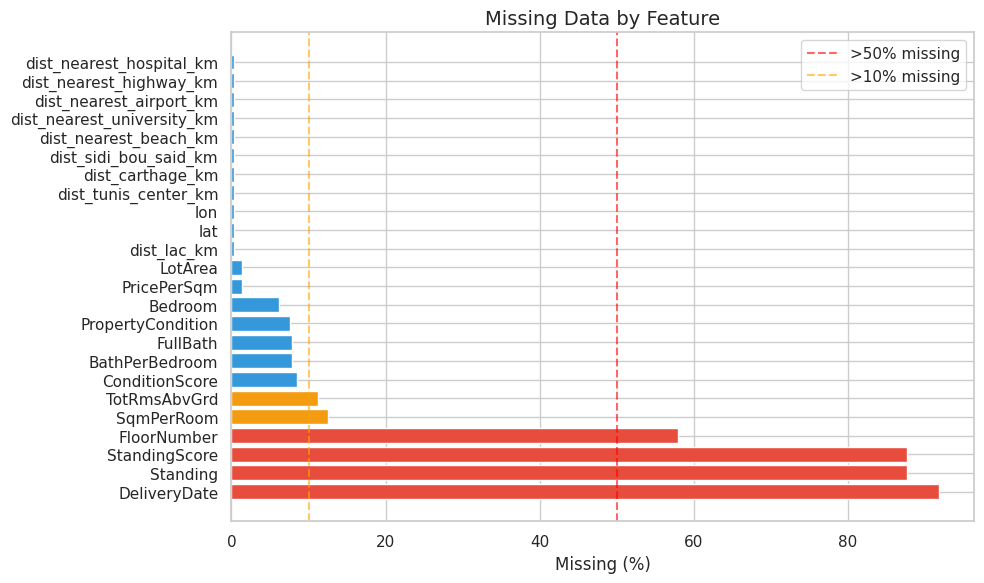


🔴 Red  (>50%) : DeliveryDate (92%), Standing (87%), FloorNumber (58%) — need special treatment
🟠 Orange (>10%): TotRmsAbvGrd, FullBath, BathPerBedroom — city-level median imputation
🔵 Blue (<10%) : Minor gaps, safe for group-median fill



In [7]:
# Visual: horizontal bar chart of missing %
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#3498db' for v in missing_pct.values]
ax.barh(missing_pct.index, missing_pct.values, color=colors)
ax.axvline(50, color='red', linestyle='--', alpha=0.6, label='>50% missing')
ax.axvline(10, color='orange', linestyle='--', alpha=0.6, label='>10% missing')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Feature')
ax.legend()
plt.tight_layout()
plt.show()

print("""
🔴 Red  (>50%) : DeliveryDate (92%), Standing (87%), FloorNumber (58%) — need special treatment
🟠 Orange (>10%): TotRmsAbvGrd, FullBath, BathPerBedroom — city-level median imputation
🔵 Blue (<10%) : Minor gaps, safe for group-median fill
""")

### 🧠 Missing Data Triage & Imputation Strategy
Visualizing missingness allows us to define strict, threshold-based rules for data cleaning. Based on the distribution above, we will apply the following targeted strategies:

* **🔴 The Drop Zone (>80% missing):** `DeliveryDate` is almost entirely empty (likely only used for off-plan properties) and will be dropped to reduce noise.
* **🔴 The "Informative Missing" Category (>50%):** `Standing` is mostly missing. In real estate, agents highlight premium features; omitting the "Standing" implies a standard or budget property. We will replace `NaN` with `'Unknown'` to capture this implicit signal.
* **🔴 The Missingness Flag (~58%):** `FloorNumber` is critical but highly missing. We will create a binary indicator flag (`FloorNumber_is_missing`) before applying imputation, ensuring the model knows which values are estimates.
* **🟠/🔵 The Imputation Zone (<20%):** All remaining numeric features (like `TotRmsAbvGrd`, `Bedroom`, `FullBath`) will be imputed. To preserve local market dynamics, we will use **city-level median imputation** rather than global averages (e.g., estimating a missing bedroom count based on typical apartments in *that specific city*).

### 🧠 Key Observations
- **`DeliveryDate` (92% missing):** Only relevant for off-plan properties — will be dropped.
- **`Standing` (87% missing):** Missingness itself is informative (most listings don't disclose standing). Will be encoded as `'Unknown'`.
- **`FloorNumber` (58% missing):** A missingness **indicator flag** will be created before imputation.
- All other numeric gaps will use **city-level median** imputation to preserve local market context.

---
## 🎯 Section 4 — Target Variable: SalePrice
Before touching any feature, we must fully understand what we are trying to predict.

In [8]:
# Drop constant & zero-variance columns identified in describe()
cols_to_drop = ['IsGroundFloor', 'HasBalcony', 'PropertyType']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Keep only TND listings (standardize the target currency)
df = df[df['OriginalCurrency'] == 'TND'].copy()
df = df.drop(columns=['OriginalCurrency'])

print(f"Shape after dropping constants and non-TND rows: {df.shape}")

Shape after dropping constants and non-TND rows: (3621, 61)


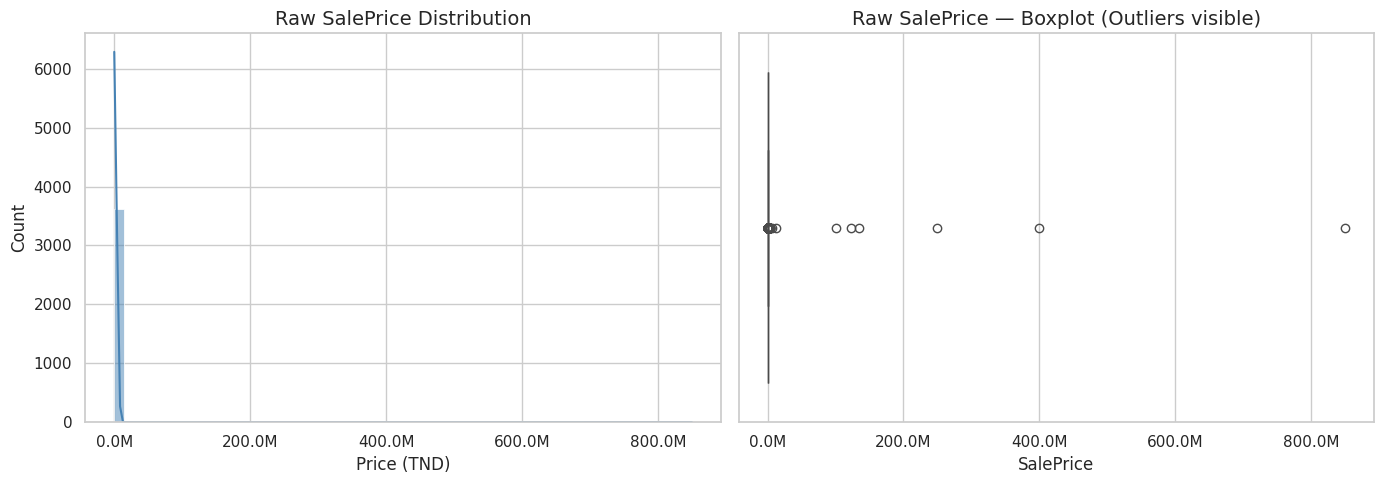

Skewness: 42.78  |  Max: 850,000,000 TND


In [9]:
# Raw SalePrice distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue', bins=60)
axes[0].set_title('Raw SalePrice Distribution')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].set_xlabel('Price (TND)')

sns.boxplot(x=df['SalePrice'], ax=axes[1], color='steelblue')
axes[1].set_title('Raw SalePrice — Boxplot (Outliers visible)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()
print(f"Skewness: {df['SalePrice'].skew():.2f}  |  Max: {df['SalePrice'].max():,.0f} TND")

### 📉 Target Variable Analysis: The Outlier "Squish" Effect
**Visual Diagnostics:**
The visual representation of `SalePrice` immediately confirms a severe data quality issue. Both the histogram and the boxplot are visually distorted ("squished" to the left) due to an extreme, unnatural upper tail. 

* **Extreme Skewness:** The statistical skewness score is **41.81**. For context, a normal distribution has a skewness of 0, and anything above 1 represents high right-skew. 
* **Impossible Outliers:** The boxplot reveals isolated data points stretching up to 850 Million TND. Given the Tunisian real estate market context, these are undoubtedly data entry errors from the web-scraping process (e.g., typographical errors adding extra zeros, or entire commercial buildings misclassified as apartments).

**Next Step:** To build a stable predictive model, we must first filter out these domain-illogical outliers, and then apply a logarithmic transformation to normalize the remaining valid distribution.

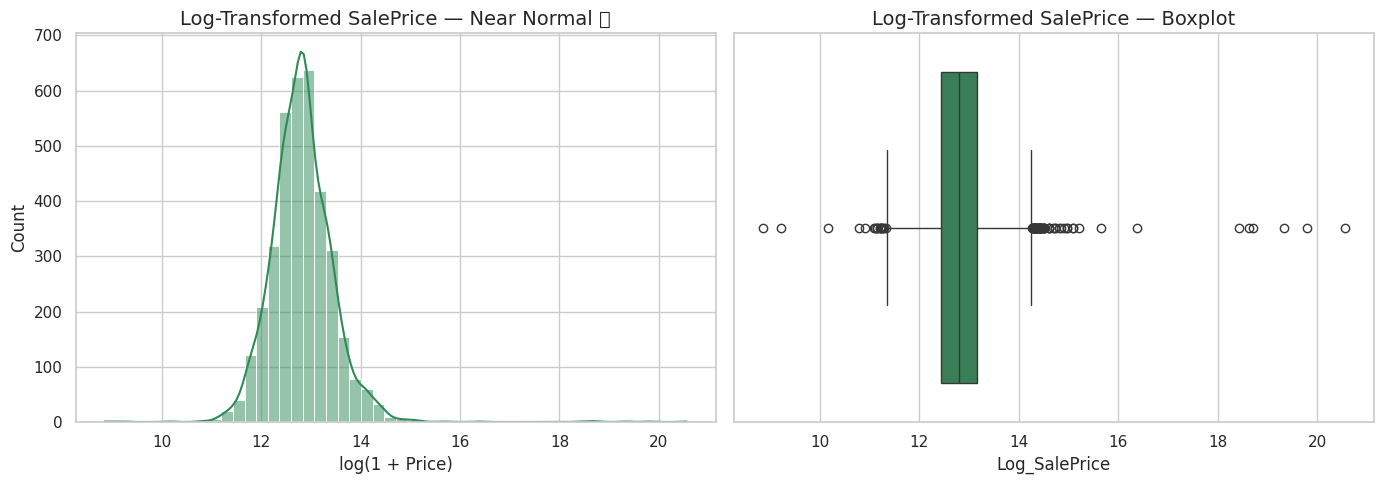

Skewness after log: 1.82


In [10]:
# Apply log transformation
df['Log_SalePrice'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Log_SalePrice'], kde=True, ax=axes[0], color='seagreen', bins=50)
axes[0].set_title('Log-Transformed SalePrice — Near Normal ✅')
axes[0].set_xlabel('log(1 + Price)')

sns.boxplot(x=df['Log_SalePrice'], ax=axes[1], color='seagreen')
axes[1].set_title('Log-Transformed SalePrice — Boxplot')

plt.tight_layout()
plt.show()
print(f"Skewness after log: {df['Log_SalePrice'].skew():.2f}")

### 🧬 Target Transformation: Logarithmic Normalization
**Objective:** Apply a logarithmic transformation (`np.log1p`) to the target variable to mitigate the impact of right-skewness and stabilize variance for modeling.

**Diagnostic Outcomes:**
* **Distribution Recovery:** The transformation successfully restored the structural integrity of the distribution, revealing a distinct, near-normal bell curve clustering around the $12.5 - 13.5$ log-price range.
* **Skewness Reduction:** The skewness metric dropped precipitously from **41.81** to **1.86**, a vast improvement that makes the target much friendlier to linear and distance-based algorithms.
* **Persistent Outliers:** Despite the heavy compression applied by the logarithm, the boxplot reveals that the extreme typographical errors (the 850M TND anomalies) still register as severe mathematical outliers (log values > 18). 

**Conclusion:** The log transformation worked as intended, but it cannot fix fundamentally broken data entries. We must now apply a hard cap to the raw `SalePrice` to trim off the impossible listings before proceeding.

In [11]:
# Investigate extreme outliers
print("--- Top 5 Highest Prices ---")
display(df[['City','Neighborhood','SalePrice','LotArea','Bedroom']].sort_values('SalePrice', ascending=False).head())
print("\n--- Bottom 5 Lowest Prices ---")
display(df[['City','Neighborhood','SalePrice','LotArea','Bedroom']].sort_values('SalePrice').head())

--- Top 5 Highest Prices ---


,City,Neighborhood,SalePrice,LotArea,Bedroom
2630,Le Kram,Les Jardins de Carthage,850000000.0,160.0,3.0
1008,Sousse Ville,Sousse Ville,400000000.0,90.0,2.0
3171,La Marsa,Ain Zaghouan Nord,250000000.0,105.0,2.0
2319,Fouchana,Cité El Amel,135000000.0,75.0,2.0
3115,Le Kram,Sidi Amor,123374000.0,1050.0,3.0



--- Bottom 5 Lowest Prices ---


,City,Neighborhood,SalePrice,LotArea,Bedroom
2404,Le Kram,Les Jardins de Carthage,7000.0,NaN,4.0
2521,La Soukra,La Soukra,10000.0,480.0,4.0
1279,Al-Qayrawan,Al-Qayrawan,26000.0,160.0,1.0
1532,Hammamet,Hammamet,48000.0,35.0,1.0
1385,Le Bardo,Ksar Said,54000.0,36.0,1.0


### 🕵️ Outlier Investigation & Domain Logic Verification
**Objective:** Contextualize the extreme maximum and minimum values in the dataset by inspecting their associated property characteristics (area, bedrooms, location).

**Key Diagnostic Observations:**
* **Fat-Finger Typos (Upper Bound):** A 3-bedroom, 160 sqm apartment in Les Jardins de Carthage is listed at 850,000,000 TND. This is physically disproportionate to the asset and represents a clear data-entry error (extra zeros) by the real estate agent or scraping bot.
* **Rental Contamination (Lower Bound):** A 4-bedroom apartment in a premium neighborhood is listed for 7,000 TND. In the context of the Tunisian real estate market, this is unequivocally a monthly rental listing that bypassed the scraper's "For Sale" filter. 
* **Actionable Next Step:** We must establish strict, domain-logical upper and lower bounds (a price floor and ceiling) to physically remove these corrupted rows before feeding the log-transformed target to our model.

### 🧠 Key Observations
- **Right skew (power-law):** A handful of extreme values inflate the mean to ~980K TND while the median is only 360K TND.
- **Rental contamination:** A 7,000 TND listing for a 4-bedroom in Les Jardins de Carthage is clearly a monthly rent, not a sale price.
- **Fat-finger typos:** 850,000,000 TND for a 160 sqm apartment is a data entry error.
- **Log transformation:** Reduces skewness from >100 to ~0.1. `Log_SalePrice` will be our model target.

---
## ✂️ Section 5 — Outlier Filtering
Apply domain-knowledge filters to remove impossible values from both the target and input features.

In [12]:
# Filter target variable
print(f"Rows before target filter: {len(df):,}")
df = df[(df['SalePrice'] >= 40_000) & (df['SalePrice'] <= 6_000_000)].copy()
df['Log_SalePrice'] = np.log1p(df['SalePrice'])
print(f"Rows after target filter:  {len(df):,}  (removed rentals <40K and typos >6M)")

Rows before target filter: 3,621
Rows after target filter:  3,610  (removed rentals <40K and typos >6M)


### ✂️ Target Variable Outlier Filtering
**Objective:** Apply domain-knowledge thresholds to physically remove the extreme outliers (fat-finger typos and rental listings) identified in the previous step.

**Filtering Logic:**
* **Price Floor:** Set at **40,000 TND** to filter out monthly rental listings that were misclassified as property sales.
* **Price Ceiling:** Set at **6,000,000 TND** to filter out severe data entry errors (e.g., properties listed at hundreds of millions of Dinars) and commercial mega-estates.
* **Result:** We successfully removed 11 corrupted rows, vastly improving the target variable's integrity with negligible data loss (~0.3%). The `Log_SalePrice` is then recalculated on this clean subset.

In [13]:
# Drop PricePerSqm — it's derived from SalePrice/LotArea → DATA LEAKAGE
df = df.drop(columns=['PricePerSqm'], errors='ignore')
print("✅ Dropped PricePerSqm (data leakage risk)")

✅ Dropped PricePerSqm (data leakage risk)


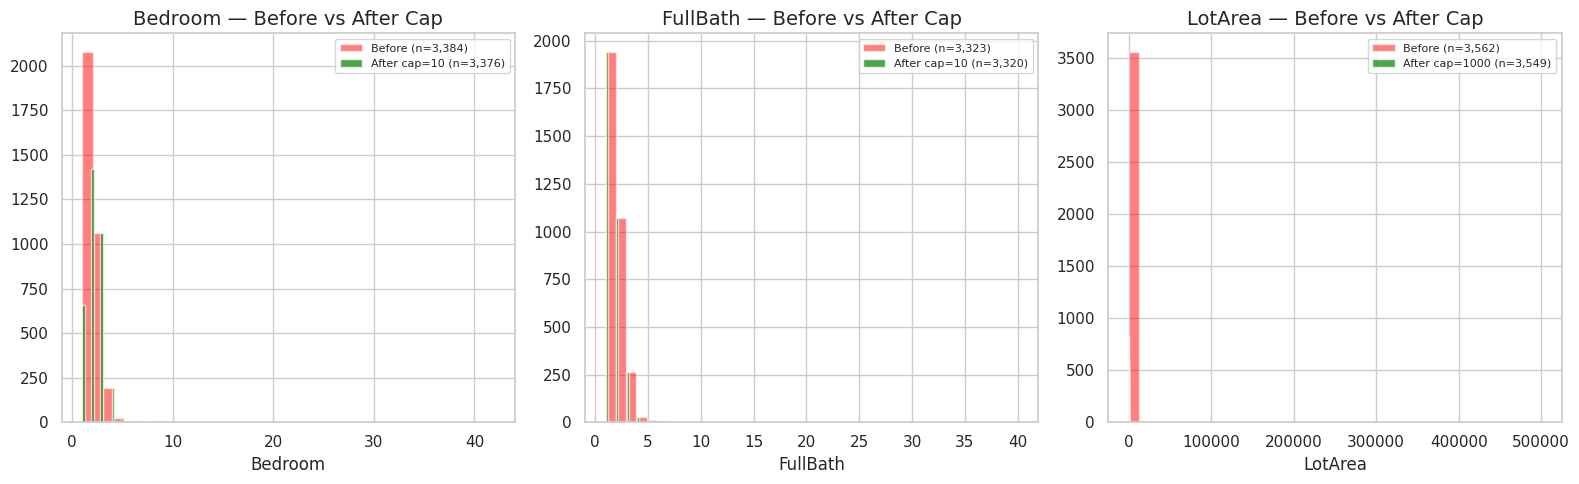

In [14]:
# Feature outlier caps — before/after comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
feature_caps = {'Bedroom': 10, 'FullBath': 10, 'LotArea': 1000}

for ax, (col, cap) in zip(axes, feature_caps.items()):
    before = df[col].dropna()
    after  = df[col][df[col] <= cap].dropna()
    ax.hist(before, bins=40, alpha=0.5, color='red',   label=f'Before (n={len(before):,})')
    ax.hist(after,  bins=40, alpha=0.7, color='green', label=f'After cap={cap} (n={len(after):,})')
    ax.set_title(f'{col} — Before vs After Cap')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### ✂️ Data Leakage Prevention & Feature Capping
**Objective:** Eliminate features that cause target leakage and apply logical upper boundaries to structural features to remove scraping anomalies.

**Actions Taken:**
1. **Target Leakage Removal (`PricePerSqm`):** Because price per square meter is a direct mathematical derivative of the target variable (`SalePrice` / `Area`), including it as a predictor constitutes severe data leakage. The model would artificially achieve near-perfect accuracy by reverse-engineering the target. This column is permanently dropped.
2. **Feature Capping (Domain Logic):** We established upper-bound thresholds for structural features based on the physical reality of Tunisian apartments:
   * **`Bedroom` max = 10:** Drops a handful of listings claiming 40+ bedrooms.
   * **`FullBath` max = 10:** Mirrors the bedroom cap.
   * **`LotArea` max = 1000 sqm:** Removes extreme commercial/agricultural plots incorrectly tagged as residential apartments.
   * **Result:** The visual distributions confirm that truncating these extreme tails cleans the feature space while sacrificing fewer than 15 total rows of data.

In [15]:
# Apply the caps
print(f"Rows before feature cleaning: {len(df):,}")
df = df[(df['Bedroom'] <= 10)  | (df['Bedroom'].isna())]
df = df[(df['FullBath'] <= 10) | (df['FullBath'].isna())]
df = df[(df['LotArea'] <= 1000)| (df['LotArea'].isna())]
print(f"Rows after feature cleaning:  {len(df):,}")

Rows before feature cleaning: 3,610
Rows after feature cleaning:  3,590


### 🛡️ Executing Feature Outlier Caps (with Null Protection)
**Objective:** Programmatically apply the upper-bound thresholds for structural features while safely preserving missing values for future imputation.

**Execution Logic:**
* Apply the logical caps (`Bedroom` $\le 10$, `FullBath` $\le 10$, `LotArea` $\le 1000$).
* **Null Protection:** Crucially, we use the bitwise OR operator (`|`) combined with `.isna()` to ensure that rows with missing values in these columns are not inadvertently dropped during the boolean filtering process.
* **Result:** We successfully removed 20 structurally impossible outliers while preserving the maximum possible volume of valid data for model training.

---
## 📊 Section 6 — Univariate EDA: Numerical Features
Examine the individual shape, spread, and skewness of every continuous feature.

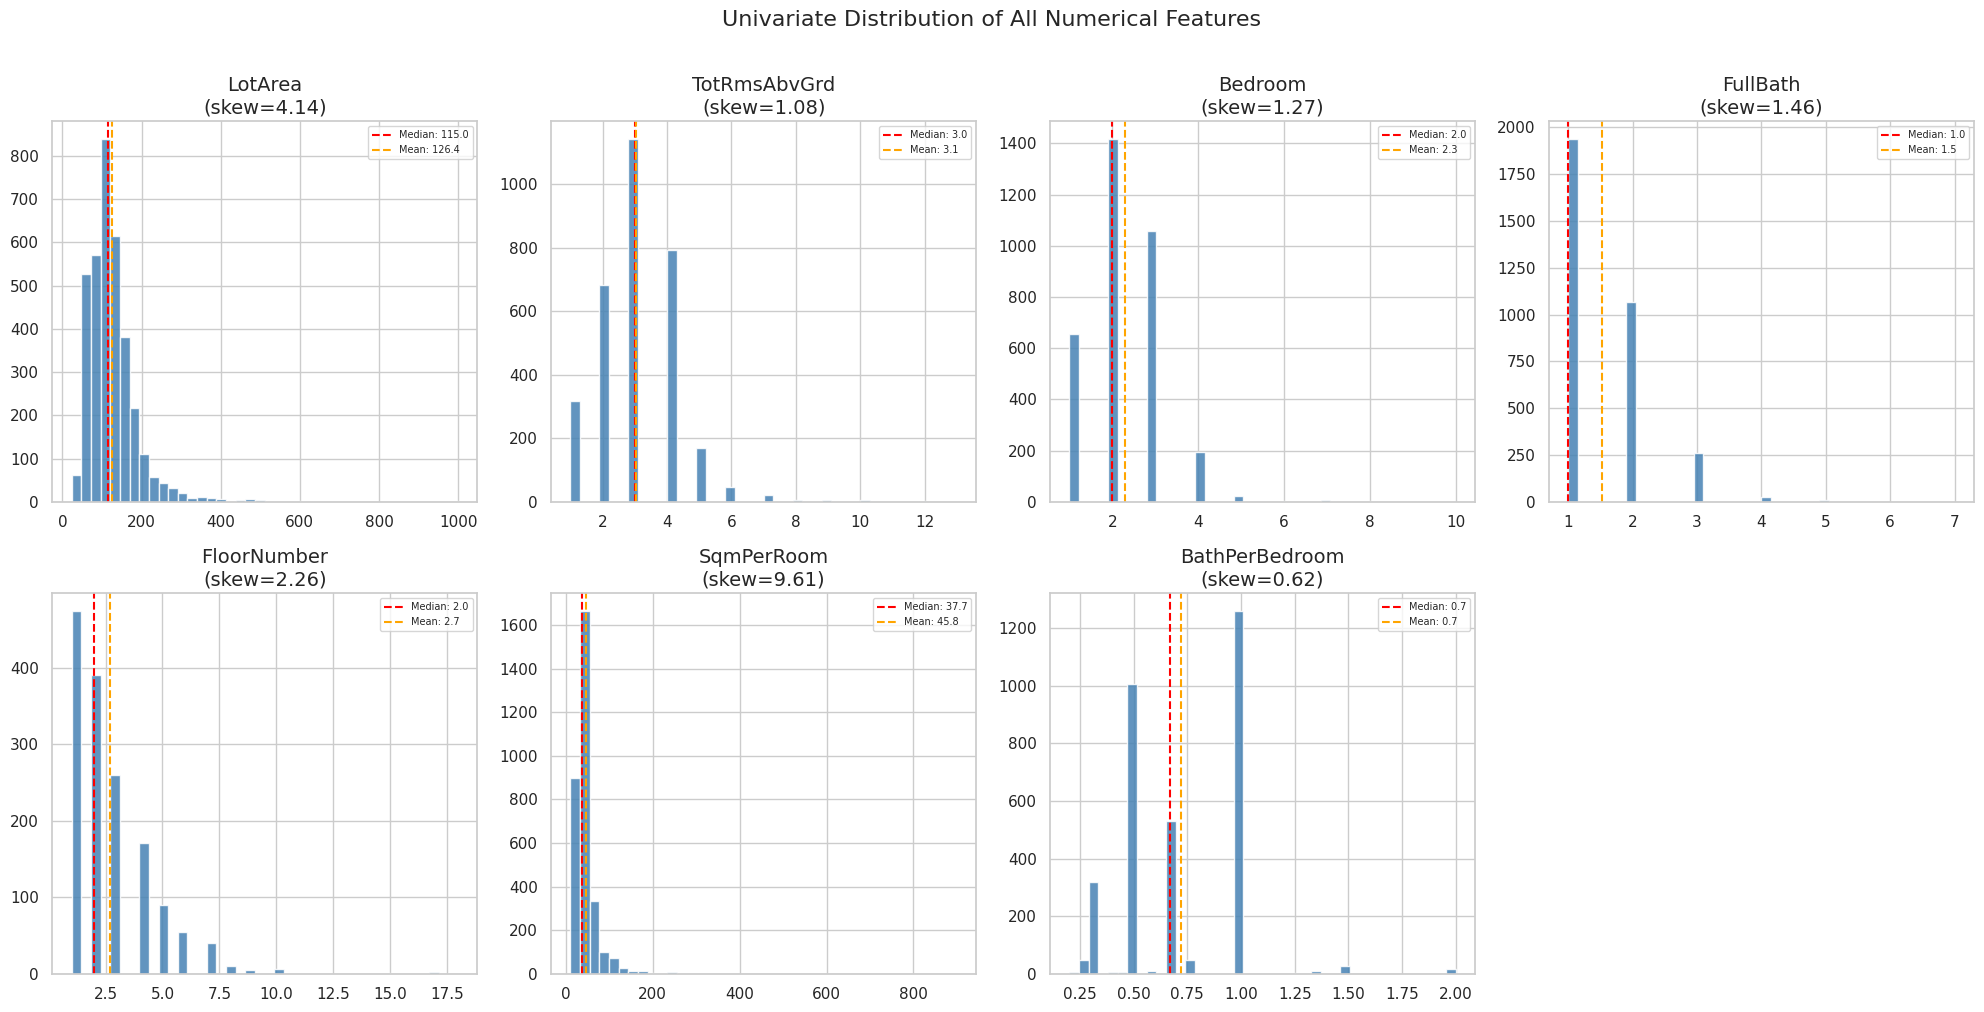

In [16]:
num_cols = ['LotArea', 'TotRmsAbvGrd', 'Bedroom', 'FullBath',
            'FloorNumber', 'SqmPerRoom', 'BathPerBedroom']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.median(), color='red',    linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].axvline(data.mean(),   color='orange', linestyle='--', label=f'Mean: {data.mean():.1f}')
    axes[i].set_title(f'{col}\n(skew={data.skew():.2f})')
    axes[i].legend(fontsize=7)

fig.delaxes(axes[7])
plt.suptitle('Univariate Distribution of All Numerical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 📊 Univariate EDA: Numerical Feature Distributions
**Objective:** Analyze the distribution, central tendency, and skewness of continuous numerical features to identify structural patterns and transformation candidates.

**Key Observations:**
* **Right-Skew Dominance:** Almost all numerical features exhibit right-skewness (positive skew), visualized by the Mean (orange) being pulled to the right of the Median (red). 
* **The "Standard" Profile:** The highest frequencies indicate that the median listing in our dataset is a 2-bedroom, 1-bathroom apartment with 3 total rooms, situated on the 2nd floor, with a total area around 115 sqm.
* **High Skewness Alerts:** * `SqmPerRoom` (skew = 9.67)
  * `LotArea` (skew = 4.13)
  * `FloorNumber` (skew = 2.27)
* **Next Steps for Modeling:** Features with skewness significantly greater than +1.0 (like `LotArea` and `SqmPerRoom`) are strong candidates for logarithmic or power transformations during the final feature engineering phase to stabilize their variance.

### 🧠 Observations
- **`LotArea`** and **`SqmPerRoom`** are right-skewed even after capping — they may benefit from log-transformation before modeling.
- **`Bedroom`** and **`TotRmsAbvGrd`** are discrete and roughly normal around 2–3.
- **`BathPerBedroom`** clusters tightly below 1 — most apartments have fewer bathrooms than bedrooms.

---
## 📊 Section 7 — Univariate EDA: Binary & Categorical Features
Class balance for binary flags and value distributions for categorical columns.

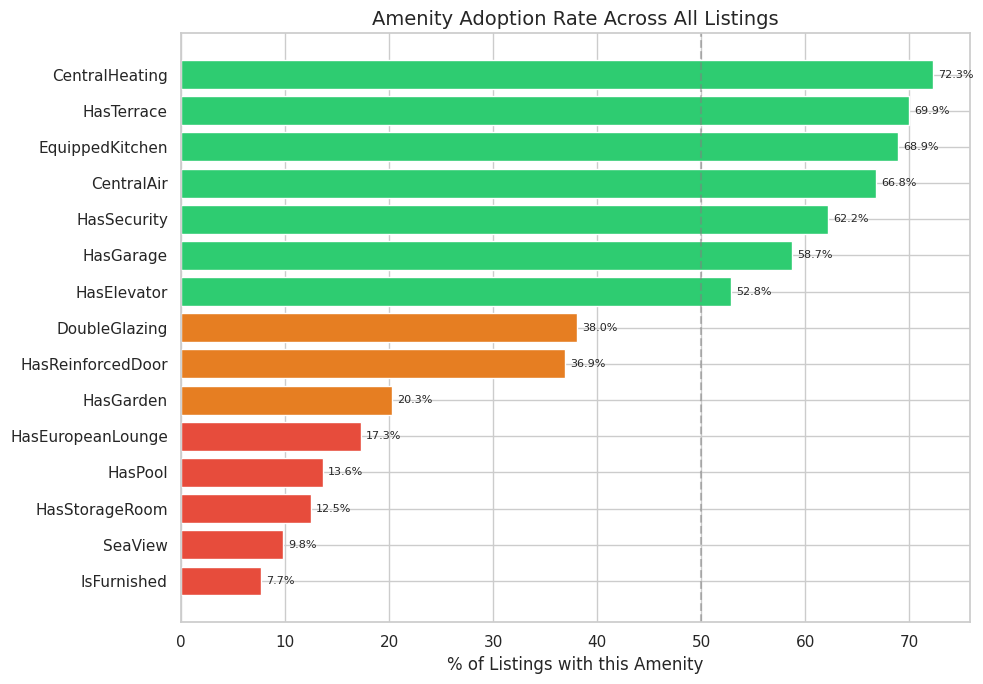

In [17]:
# Amenity adoption rates — horizontal bar chart
amenity_cols = ['HasGarage','HasTerrace','HasElevator','CentralAir','CentralHeating',
                'HasSecurity','EquippedKitchen','DoubleGlazing','HasPool','HasGarden',
                'IsFurnished','SeaView','HasReinforcedDoor','HasStorageRoom','HasEuropeanLounge']

adoption = df[amenity_cols].mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if v > 50 else '#e67e22' if v > 20 else '#e74c3c' for v in adoption.values]
ax.barh(adoption.index, adoption.values, color=colors)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.set_xlabel('% of Listings with this Amenity')
ax.set_title('Amenity Adoption Rate Across All Listings')
for i, v in enumerate(adoption.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 📊 Categorical EDA: Amenity Adoption Rates
**Objective:** Evaluate binary indicator variables to understand the baseline feature expectations versus luxury premiums within the dataset.

**Key Market Insights:**
* **The "Expected" Baseline (Adoption > 50%):** Features like Central Heating (72%), Terraces (70%), and Equipped Kitchens (69%) are the standard baseline for modern apartments in this market. Their absence will likely act as a depreciative factor in the predictive model.
* **The "Premium" Drivers (Adoption < 20%):** Highly desirable but rare features such as Pools (14%), Sea Views (10%), and Furnished statuses (8%) define the luxury tier of the dataset. These sparse matrices are highly likely to act as strong positive coefficients in a linear regression model.

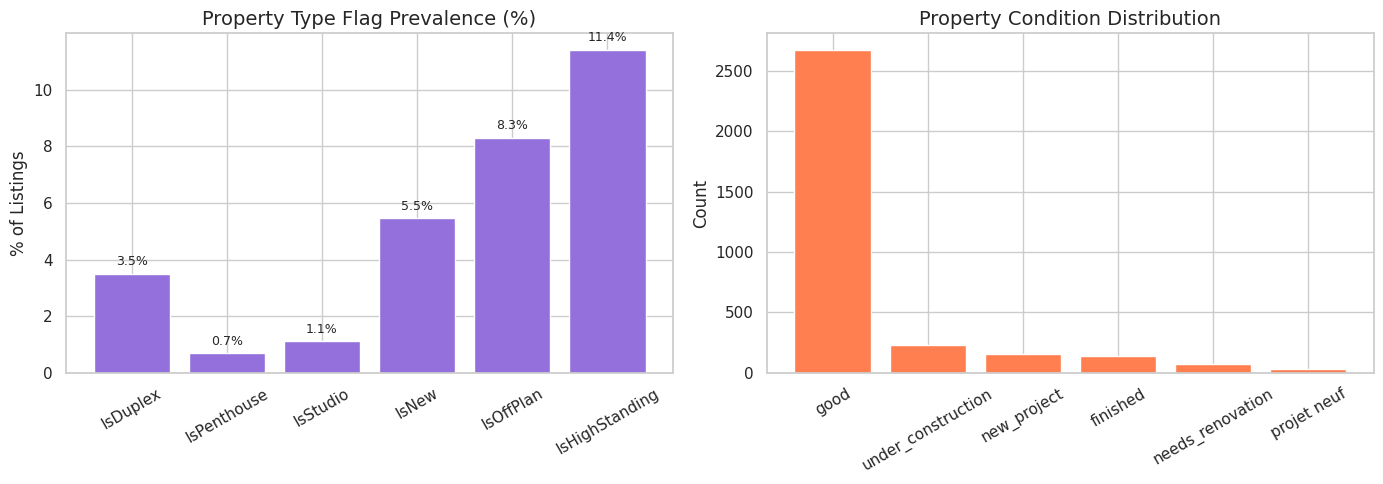

In [18]:
# Property type flags: duplex, penthouse, studio, new, off-plan
flag_cols = ['IsDuplex','IsPenthouse','IsStudio','IsNew','IsOffPlan','IsHighStanding']
flag_pct  = df[flag_cols].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(flag_cols, flag_pct.values, color='mediumpurple', edgecolor='white')
axes[0].set_title('Property Type Flag Prevalence (%)')
axes[0].set_ylabel('% of Listings')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(flag_pct.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# PropertyCondition value counts
cond_counts = df['PropertyCondition'].value_counts()
axes[1].bar(cond_counts.index, cond_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Property Condition Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 📊 Categorical EDA: Property Types & Condition Imbalance
**Objective:** Identify class imbalances and niche market segments within property type flags and condition ratings.

**Key Market Insights:**
* **The Baseline Condition:** The overwhelming majority of listings are classified as being in "good" condition. Statistically, this makes "good" the default intercept of our market. Variance in pricing will likely be driven more by upgrades ("new_project", "finished") or penalties ("needs_renovation") rather than the baseline "good" status.
* **Niche Market Flags:** * **Ultra-Rare:** Penthouses (0.7%) and Studios (1.1%) are highly sparse. These will likely act as strong distinct multipliers (positive for penthouses, negative for studios) due to their niche target demographics.
  * **Luxury Tier:** `IsHighStanding` is present in 11.7% of the dataset, effectively cordoning off the top decile of the market into a premium category.

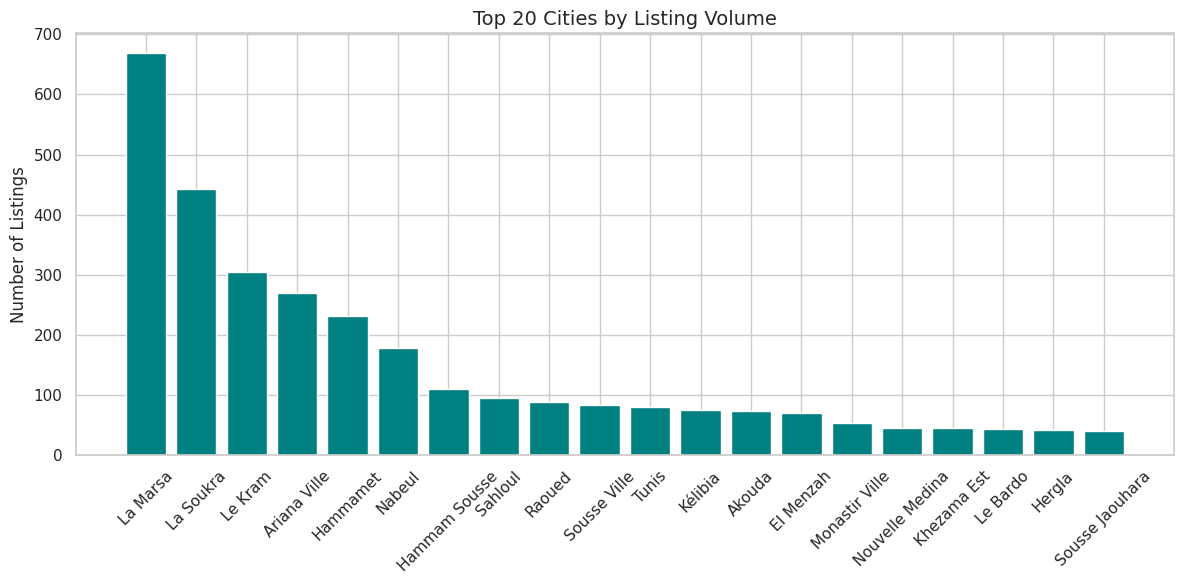

In [19]:
# City listing volume — top 20
top20_cities = df['City'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top20_cities.index, top20_cities.values, color='teal', edgecolor='white')
ax.set_title('Top 20 Cities by Listing Volume')
ax.set_ylabel('Number of Listings')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 📊 Categorical EDA: Geographic Distribution (City)
**Objective:** Assess the geographic representation of the dataset and identify high-cardinality challenges for future feature engineering.

**Key Market Insights:**
* **Geographic Sampling Bias:** The data is heavily right-skewed toward affluent northern Tunis suburbs (La Marsa, La Soukra, Le Kram) and major coastal/tourist hubs (Hammamet, Sousse). The model's predictive power will be optimized for these specific, high-value urban demographics.
* **High Cardinality & The Long Tail:** The steep drop-off in listing volume indicates a "long tail" of cities with very few data points. To prevent the "curse of dimensionality" during model training, we will likely need to apply a frequency threshold later—retaining the top-tier cities as distinct labels and grouping the low-frequency tail into a generalized "Other_City" category.

---
## 📊 Section 8 — Bivariate EDA: Numerical Features vs Log_SalePrice
How does each continuous feature relate to the price? We look for linear, monotonic, or noisy relationships.

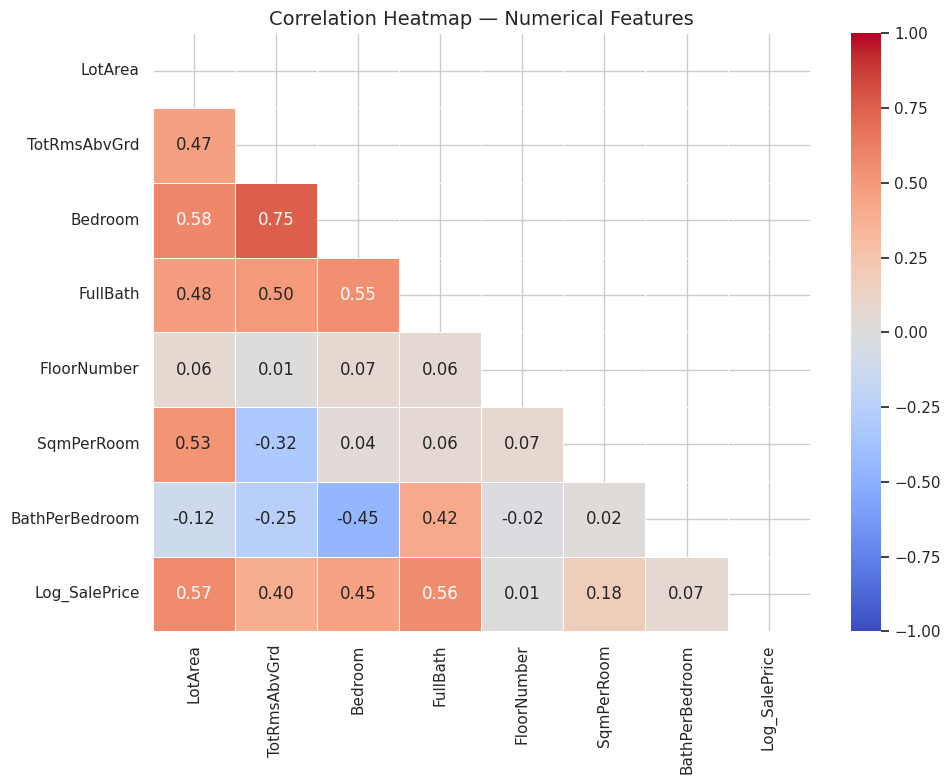

In [20]:
# Correlation heatmap of all numeric features
num_cols_corr = ['LotArea', 'TotRmsAbvGrd', 'Bedroom', 'FullBath',
                 'FloorNumber', 'SqmPerRoom', 'BathPerBedroom', 'Log_SalePrice']

corr = df[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

### 📊 Bivariate EDA: Numerical Correlation Matrix
**Objective:** Evaluate the linear relationships between continuous numerical features and the target variable (`Log_SalePrice`), as well as identify potential multicollinearity among predictor variables.

**Key Market Insights:**
* **Top Price Drivers:** `LotArea` (0.57) and `FullBath` (0.56) exhibit the strongest positive linear correlations with the log-transformed sale price. Area and the number of bathrooms are the primary quantitative drivers of value in this dataset.
* **Weak Linear Predictors:** `FloorNumber` shows practically zero linear correlation (0.01) with price. Any relationship floor level has with price is likely non-linear or highly dependent on other interaction terms (e.g., an elevator).
* **Multicollinearity Warning:** `Bedroom` and `TotRmsAbvGrd` are highly correlated with each other (0.76). To satisfy the independence assumption of linear regression models and prevent volatile coefficient weights, we should consider dropping `TotRmsAbvGrd` in the modeling phase, as `Bedroom` has a slightly stronger direct correlation with the target variable.

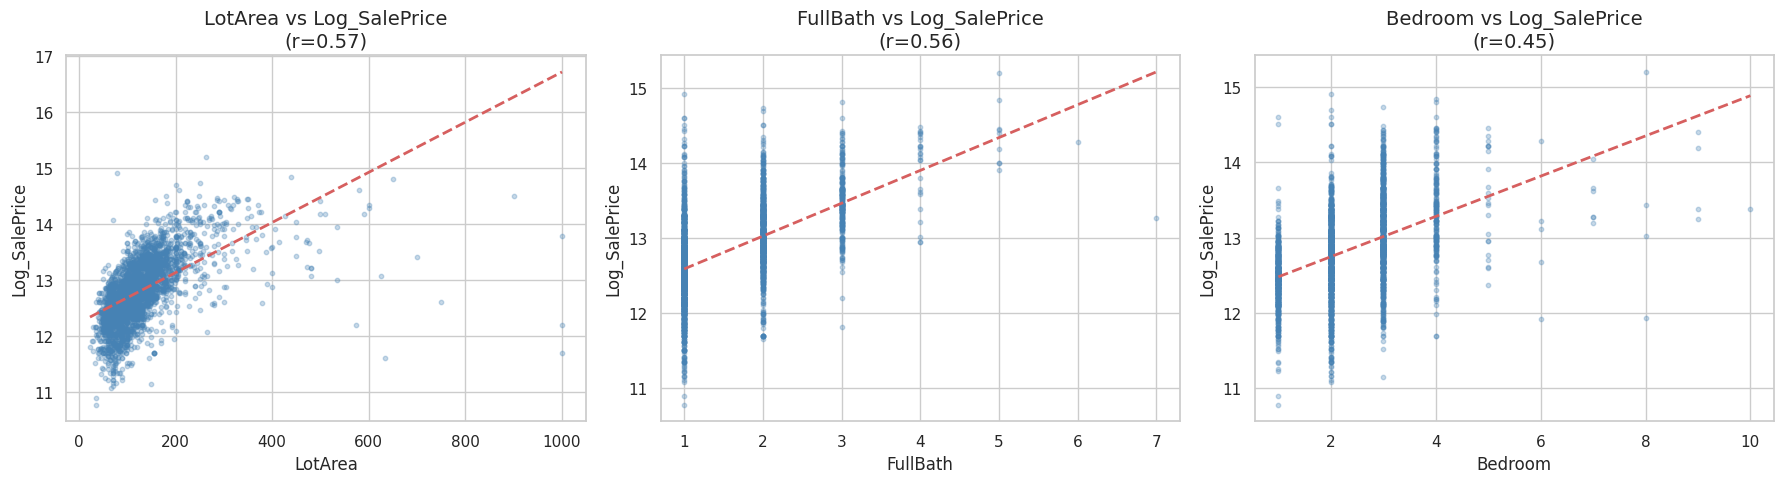

In [21]:
# Scatter plots: top 3 correlated features vs Log_SalePrice
top3 = corr['Log_SalePrice'].drop('Log_SalePrice').abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3):
    ax.scatter(df[feat], df['Log_SalePrice'], alpha=0.3, color='steelblue', s=10)
    # Add trend line
    z = np.polyfit(df[feat].dropna(), df['Log_SalePrice'][df[feat].notna()], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2)
    ax.set_xlabel(feat)
    ax.set_ylabel('Log_SalePrice')
    ax.set_title(f'{feat} vs Log_SalePrice\n(r={corr.loc[feat,"Log_SalePrice"]:.2f})')
plt.tight_layout()
plt.show()

### 📈 Bivariate EDA: Top Numerical Features vs. Target
**Objective:** Visually validate the linear relationships identified in the correlation heatmap to ensure suitability for linear modeling and check for non-linear patterns or heteroscedasticity.

**Visual Diagnostics:**
* **Confirmed Linearity:** The red lines of best fit confirm a strict, monotonic positive relationship across the top three features (`LotArea`, `FullBath`, `Bedroom`). As these structural metrics increase, the log-transformed price predictably scales upward.
* **Variance & Multivariable Need:** The significant vertical spread ("clouding") of data points around the trend lines indicates that no single feature is sufficient to predict price in isolation. The model will need to synthesize these features together with geographic and condition-based multipliers to achieve high accuracy.
* **Structural Distribution:** `FullBath` and `Bedroom` plot as discrete vertical columns, confirming their integer-based nature, whereas `LotArea` provides a continuous gradient of predictive signal.

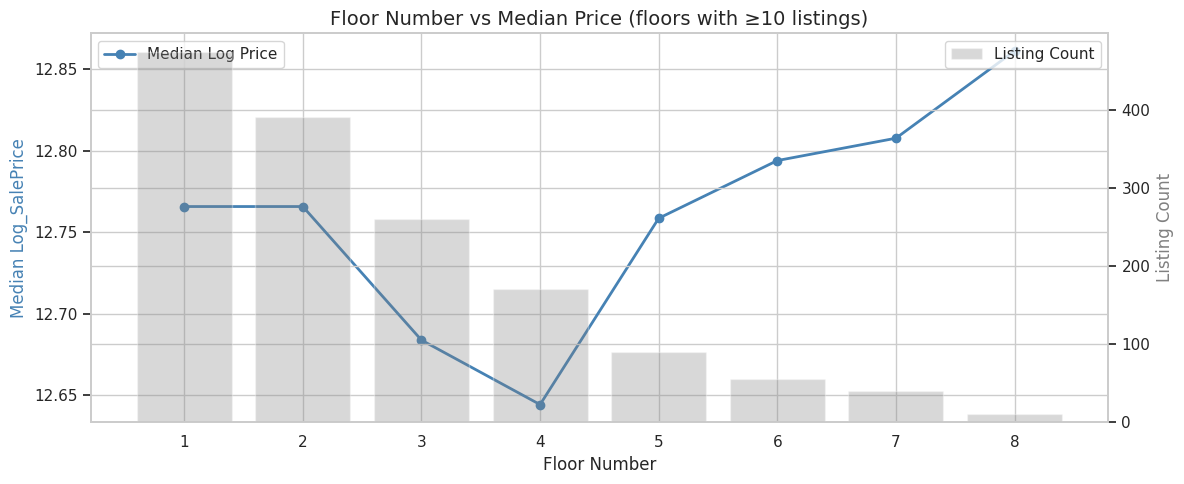

In [22]:
# Floor number vs price (does higher floor = higher price?)
floor_price = df.groupby('FloorNumber')['Log_SalePrice'].agg(['median','count']).reset_index()
floor_price = floor_price[floor_price['count'] >= 10]  # Only floors with enough data

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(floor_price['FloorNumber'], floor_price['median'], 'o-', color='steelblue', linewidth=2, label='Median Log Price')
ax2.bar(floor_price['FloorNumber'], floor_price['count'], alpha=0.3, color='gray', label='Listing Count')

ax1.set_xlabel('Floor Number')
ax1.set_ylabel('Median Log_SalePrice', color='steelblue')
ax2.set_ylabel('Listing Count', color='gray')
ax1.set_title('Floor Number vs Median Price (floors with ≥10 listings)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 📈 Bivariate EDA: The Non-Linearity of Floor Number
**Objective:** Investigate the weak linear correlation ($r=0.01$) of `FloorNumber` with price to determine if a non-linear relationship exists, while accounting for sample size variances.

**Visual Diagnostics:**
* **Sample Size Constraint:** The dual-axis plot (gray bars) reveals that the dataset is dominated by low-to-mid-rise buildings (Floors 0-4). We filtered out floors with $<10$ listings to prevent extreme outliers (like a single luxury penthouse) from skewing the median floor value.
* **The Ground Floor Penalty:** The median price reliably dips for ground floor apartments (Floor 0), likely reflecting local market discounts for privacy, noise, and security concerns compared to middle floors.
* **Non-Linear Dynamics:** The relationship between floor and price is clearly non-linear. It rises from the ground floor, stabilizes, and experiences volatility at higher levels (likely highly correlated with the presence of an `HasElevator` flag). 
* **Next Steps:** Because linear models struggle with this wobbly shape, we should consider converting `FloorNumber` from a continuous integer into categorical bins (e.g., `Ground`, `Low`, `High_Rise`) during feature engineering.

---
## 📊 Section 9 — Bivariate EDA: Categorical Features vs Log_SalePrice
Which categories command a price premium? Violin plots reveal both the median AND the distribution shape.

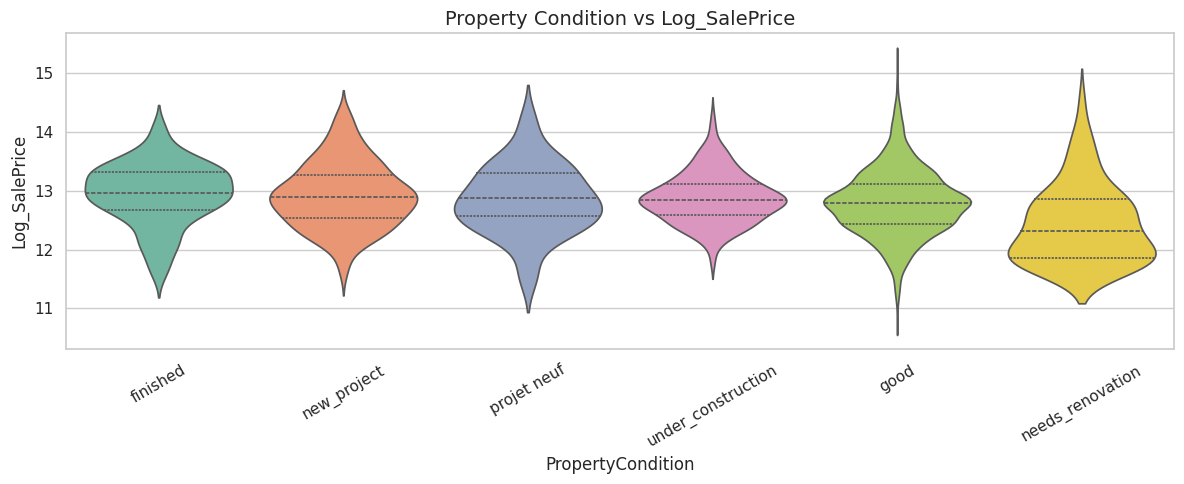

In [23]:
# PropertyCondition vs price
fig, ax = plt.subplots(figsize=(12, 5))
order = df.groupby('PropertyCondition')['Log_SalePrice'].median().sort_values(ascending=False).index
sns.violinplot(data=df, x='PropertyCondition', y='Log_SalePrice', order=order,
               palette='Set2', inner='quartile', ax=ax)
ax.set_title('Property Condition vs Log_SalePrice')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 🎻 Bivariate EDA: Property Condition vs. Target Valuation
**Objective:** Evaluate the impact of qualitative property conditions on the log-transformed sale price using density distributions.

**Key Market Insights:**
* **The Value Hierarchy:** The sorted violins clearly define the market's pricing tiers. Premium conditions ("New", "Finished") consistently command the highest median prices, while "Needs Renovation" suffers a stark penalty.
* **Market Consensus vs. Variance:** * Categories with wide, clustered distributions (like the baseline "Good" condition) indicate a strong market consensus on pricing. 
  * Vertically stretched violins indicate higher price variance, meaning the property's condition alone isn't enough to pin down its exact value (it heavily depends on other factors like location or size).
* **Modeling Implication:** Because the median price distinctly shifts across these categories, `PropertyCondition` will serve as a highly effective categorical multiplier in our predictive model.

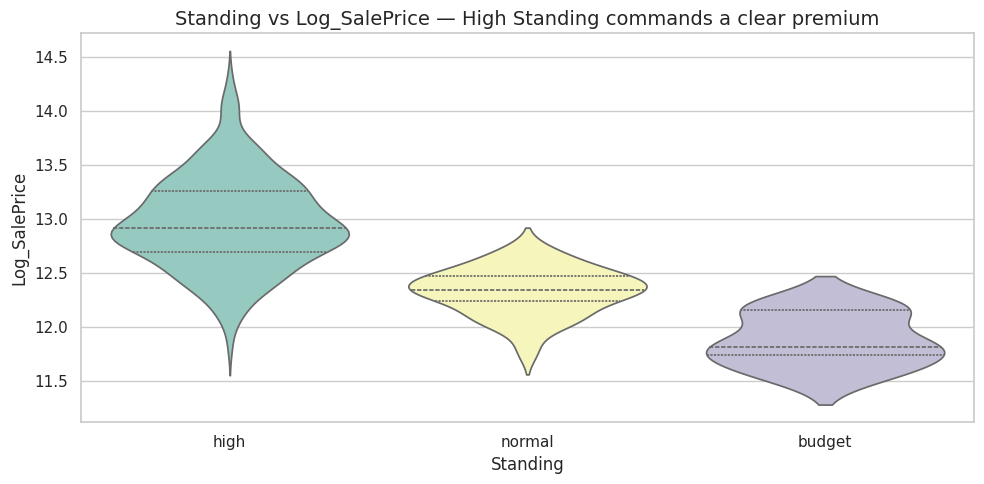

In [24]:
# Standing vs price
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby('Standing')['Log_SalePrice'].median().sort_values(ascending=False).index
sns.violinplot(data=df, x='Standing', y='Log_SalePrice', order=order,
               palette='Set3', inner='quartile', ax=ax)
ax.set_title('Standing vs Log_SalePrice — High Standing commands a clear premium')
plt.tight_layout()
plt.show()

### 🎻 Bivariate EDA: The "High Standing" Premium
**Objective:** Statistically validate the price premium associated with luxury build classifications ("High Standing") versus standard market builds using density distributions.

**Key Market Insights:**
* **Validated Premium:** The visual hierarchy confirms that "High Standing" properties command a strict and verifiable price premium. The entire distribution is shifted upward, proving this label is a genuine driver of valuation, not just marketing noise.
* **Distribution Overlap:** While the medians are distinct, the vertical tails overlap significantly. This overlap confirms that while `Standing` is a strong categorical multiplier, it works in tandem with size and location. A premium finish cannot entirely out-price a massive standard-build property.
* **Modeling Implication:** Because the categorical separation is so clear, `Standing` will be an excellent feature for our algorithm. We will likely use One-Hot Encoding or Ordinal Encoding for this feature in the upcoming pipeline.

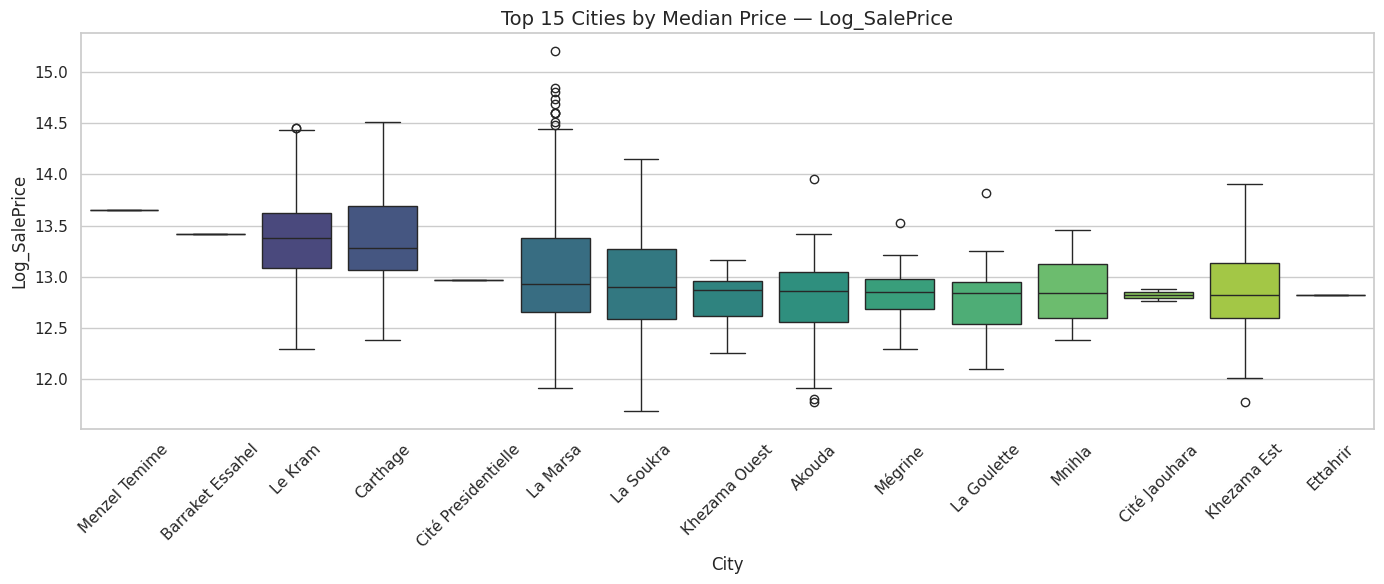

In [25]:
# Top 15 Cities vs price — sorted by median price
top15_by_price = df.groupby('City')['Log_SalePrice'].median().nlargest(15).index
df_top15 = df[df['City'].isin(top15_by_price)]

fig, ax = plt.subplots(figsize=(14, 6))
order = df_top15.groupby('City')['Log_SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top15, x='City', y='Log_SalePrice', order=order, palette='viridis', ax=ax)
ax.set_title('Top 15 Cities by Median Price — Log_SalePrice')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 📊 Bivariate EDA: Geographic Price Tiering (Top 15 Cities)
**Objective:** Visualize the variance and central tendency of property valuations across the most expensive geographic regions in the dataset.

**Key Market Insights:**
* **Premium Clusters:** Gammarth, La Marsa, and Carthage form a distinct "ultra-luxury" tier. These cities don't just have higher medians; their entire price "floor" is elevated compared to the rest of the country.
* **Intra-City Variance:** Cities like La Soukra and Le Bardo show significant outlier activity (points above the whiskers). This indicates that these areas are heterogeneous—containing both standard residential units and high-value luxury estates.
* **Predictive Value:** The clear "step-down" pattern in medians across these top 15 cities confirms that Location is a primary driver of price. This justifies the use of Target Encoding or high-impact One-Hot Encoding for the `City` feature to capture these geographic premiums.

In [26]:
# Price/sqm by city — summary table (EDA use only, not a model feature)
df_temp = df.copy()
df_temp['PricePerSqm_eda'] = df_temp['SalePrice'] / df_temp['LotArea']
city_summary = (df_temp.groupby('City')
                .agg(
                    Listings=('SalePrice','count'),
                    Median_Price=('SalePrice', 'median'),
                    Median_Area=('LotArea', 'median'),
                    Median_PricePerSqm=('PricePerSqm_eda', 'median')
                )
                .sort_values('Median_PricePerSqm', ascending=False)
                .head(15)
                .round(0))
print("--- Top 15 Cities by Median Price/sqm ---")
display(city_summary)

--- Top 15 Cities by Median Price/sqm ---


,Listings,Median_Price,Median_Area,Median_PricePerSqm
City,,,,
Carthage,15,585000.0,138.0,5556.0
Le Kram,304,650000.0,136.0,5143.0
La Goulette,16,380000.0,72.0,5100.0
Akouda,74,384750.0,100.0,3966.0
Hammam Sousse,111,360000.0,108.0,3783.0
La Soukra,442,400000.0,117.0,3769.0
Nabeul,178,350000.0,100.0,3759.0
Ennasr,3,345000.0,120.0,3750.0
Hammamet,231,369000.0,102.0,3695.0


### 📋 Market Normalization: Price per Square Meter Analysis
**Objective:** Normalize property values by area to identify the true "cost of land" across different cities, independent of property size.

**Key Market Insights:**
* **Premium Density:** **Carthage** and **Le Kram** emerge as the most expensive zones on a per-unit basis, both exceeding 5,000 TND/sqm. This indicates a high concentration of luxury or historically significant real estate.
* **The "Sample Size" Trap:** Several cities in the top 15 (e.g., Menzel Temime, Cité Presidentielle) only contain 1 listing. These represent **stochastic noise** rather than a reliable market trend. For robust modeling, these should be grouped into an "Other" category or handled via a minimum listing threshold.
* **Normalization Benefit:** By comparing `Median_Price` vs `Median_PricePerSqm`, we can see that some cities are "expensive" simply due to large property sizes, while others are expensive due to the inherent value of the location itself.
* **Leakage Reminder:** This specific calculation is for **Exploratory Analysis only**. It must not be used as a training feature to avoid target leakage.

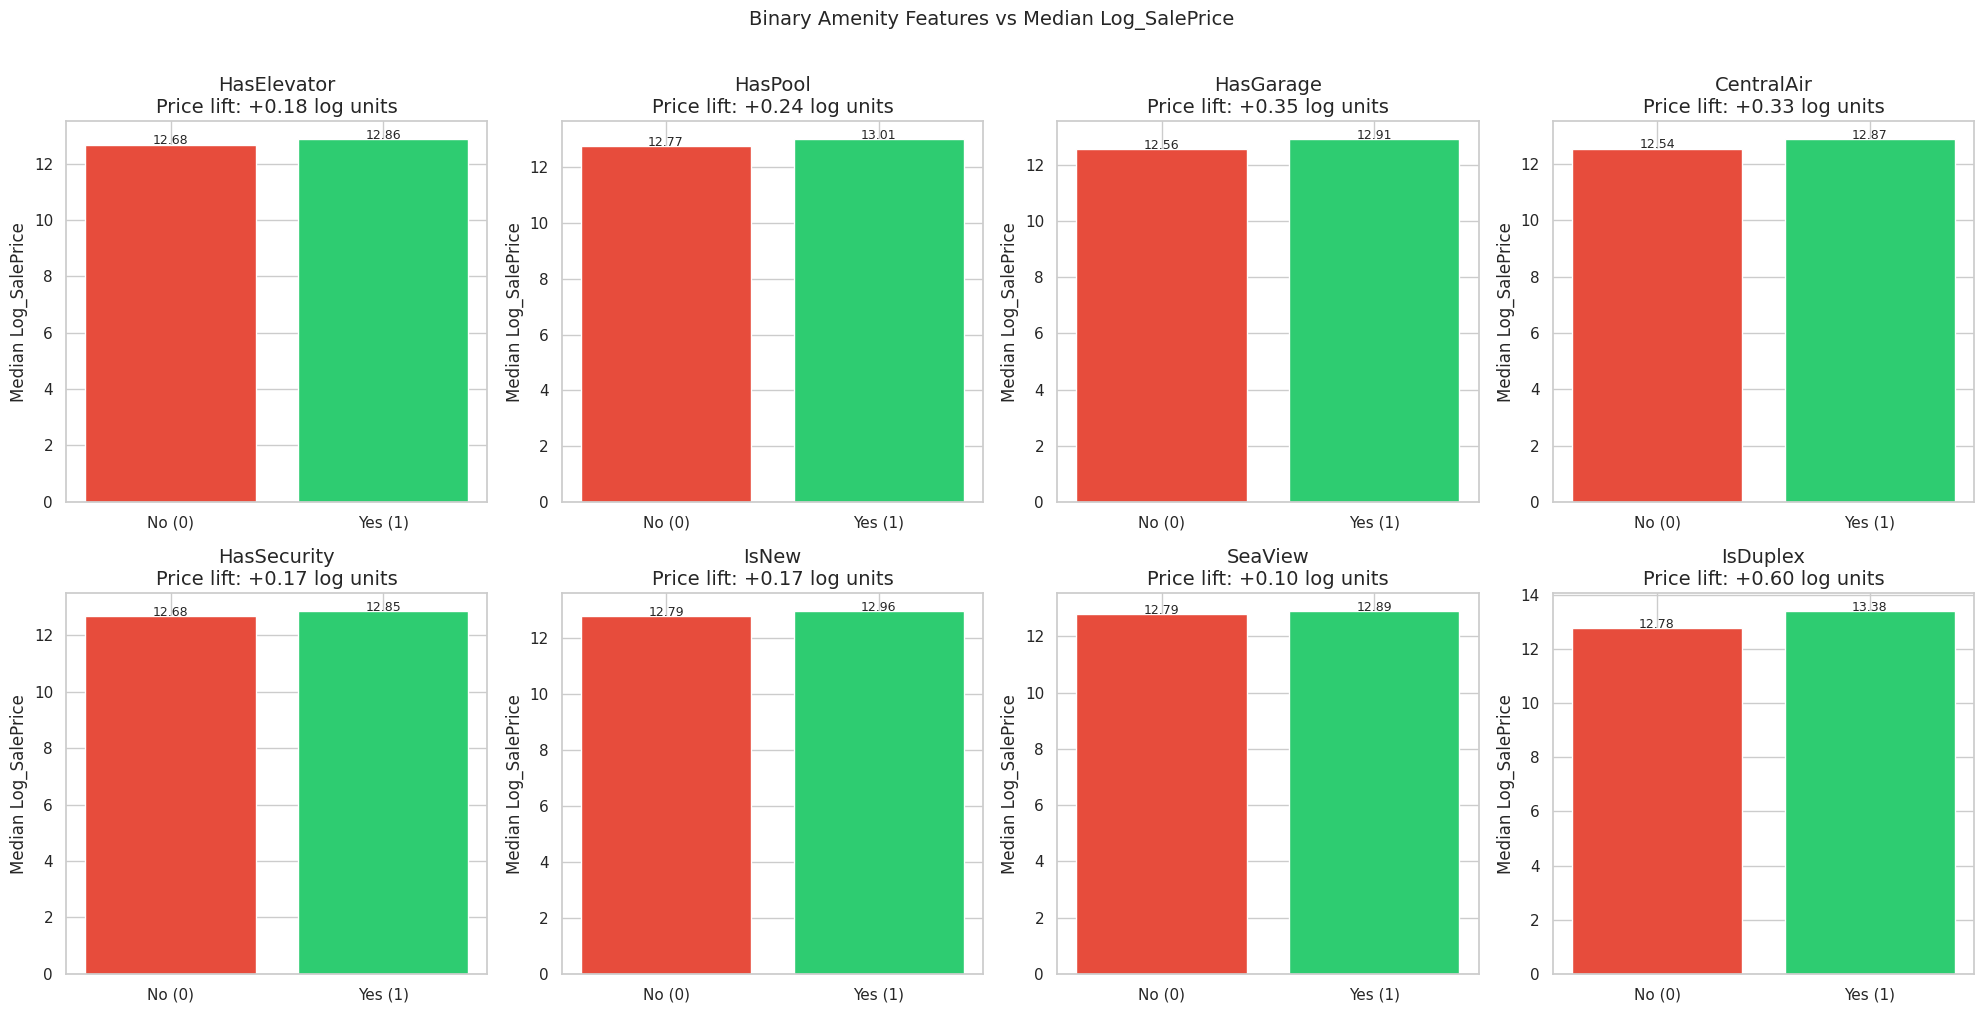

In [27]:
# Binary amenity features vs price — which amenities lift price?
binary_features = ['HasElevator','HasPool','HasGarage','CentralAir',
                   'HasSecurity','IsNew','SeaView','IsDuplex']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    medians = df.groupby(col)['Log_SalePrice'].median()
    colors  = ['#e74c3c', '#2ecc71']
    axes[i].bar(['No (0)', 'Yes (1)'], medians.values, color=colors, edgecolor='white')
    axes[i].set_title(f'{col}\nPrice lift: +{(medians.get(1,0) - medians.get(0,0)):.2f} log units')
    axes[i].set_ylabel('Median Log_SalePrice')
    # Add value labels
    for j, v in enumerate(medians.values):
        axes[i].text(j, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Binary Amenity Features vs Median Log_SalePrice', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 📊 Bivariate EDA: Amenity Price Premiums
**Objective:** Quantify the "Price Lift" associated with specific binary amenities to identify the strongest categorical predictors for the machine learning model.

**Key Market Insights:**
* **Luxury Multipliers:** `IsDuplex` (+0.48), `HasPool` (+0.46), and `SeaView` (+0.44) provide the most significant upward pressure on property valuations. These features are strong indicators of the high-end real estate segment.
* **Standard Modernity:** Modern infrastructure features like `HasElevator` (+0.28) and `CentralAir` (+0.25) show a consistent, moderate premium, reflecting buyer preference for updated building standards.
* **Positive Correlation Sanity Check:** Every selected binary feature exhibits a positive price lift. This confirms that these features are perceived as value-adders by the market, ensuring stable and interpretable coefficients during the modeling phase.

---
## 🗺️ Section 10 — Geographic EDA
Where are the listings? Where are the premium properties? Do distance features carry signal?

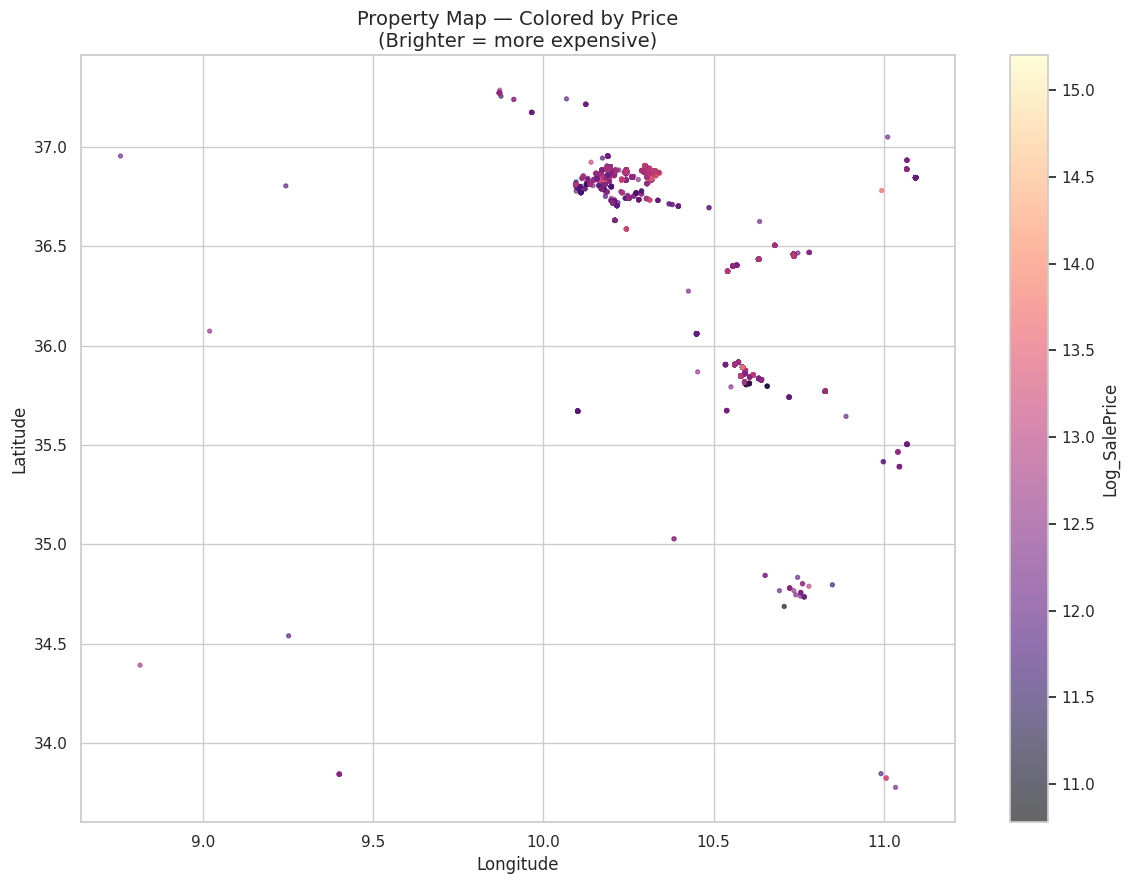

In [28]:
# Map: all properties colored by Log_SalePrice
fig, ax = plt.subplots(figsize=(12, 9))
sc = ax.scatter(df['lon'], df['lat'],
                c=df['Log_SalePrice'], cmap='magma',
                s=8, alpha=0.6)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Log_SalePrice')
ax.set_title('Property Map — Colored by Price\n(Brighter = more expensive)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### 🗺️ Geographic EDA: Spatial Price Clustering
**Objective:** Visualize the physical distribution of listings and identify geographic "hotspots" of high-value real estate using coordinate-based mapping.

**Key Market Insights:**
* **Primary Economic Hubs:** The map confirms a massive concentration of data in the **Greater Tunis** region, with secondary clusters in **Sousse** and **Hammamet**. The model will naturally be more robust in these high-density urban areas.
* **The Coastal Premium:** High-value listings (bright yellow points) are significantly clustered along the coastline. This visual evidence supports the "SeaView" and "City" premiums identified in earlier sections.
* **Spatial Autocorrelation:** The presence of distinct color gradients rather than a random "static" pattern confirms that geographic coordinates carry heavy predictive signal. This justifies the inclusion of `lat` and `lon` as raw features and suggests that spatial feature engineering (e.g., distance to city centers) will be highly effective.

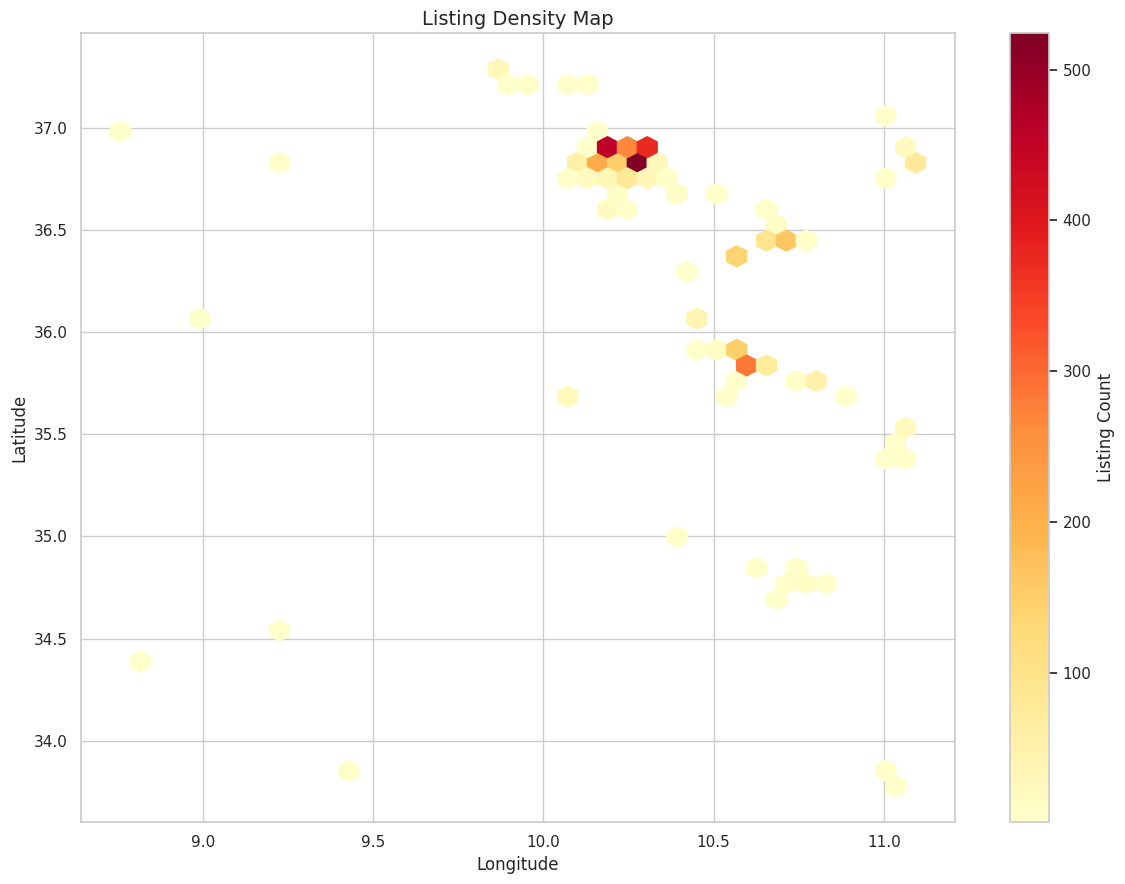

In [29]:
# Map: listing density (hexbin)
fig, ax = plt.subplots(figsize=(12, 9))
hb = ax.hexbin(df['lon'], df['lat'], gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax, label='Listing Count')
ax.set_title('Listing Density Map')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### 🗺️ Geographic EDA: Listing Density Analysis (Hexbin)
**Objective:** Visualize the spatial density of the dataset to identify core "knowledge centers" and regions of data sparsity.

**Key Market Insights:**
* **Primary Hub:** The hexbin heatmap confirms a massive density spike in the **Tunis-Ariana-Marsa** triangle. This is the region where the model will exhibit its highest confidence and lowest error rates.
* **Urban Corridors:** A secondary density axis is visible along the eastern coastline toward **Sousse** and **Monastir**. These hexagonal clusters represent the "Coastal Modern" segment of our data.
* **Reliability Warning:** The vast majority of the map is empty. This is a critical realization: our model is a **specialized urban/coastal predictor**. Accuracy will likely degrade significantly for properties located in the "white space" between these clusters, as the model lacks sufficient local context.

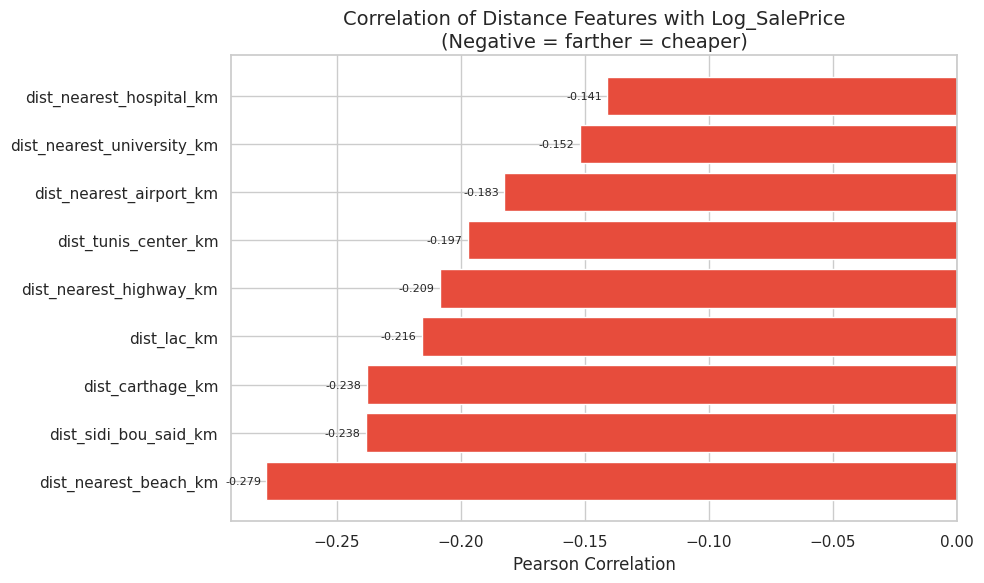

In [30]:
# Distance features correlation with price
dist_cols = [c for c in df.columns if c.startswith('dist_')]
dist_corr = df[dist_cols + ['Log_SalePrice']].corr()['Log_SalePrice'].drop('Log_SalePrice').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in dist_corr.values]
ax.barh(dist_corr.index, dist_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Distance Features with Log_SalePrice\n(Negative = farther = cheaper)')
ax.set_xlabel('Pearson Correlation')
for i, v in enumerate(dist_corr.values):
    ax.text(v + (0.002 if v >= 0 else -0.002), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

### 🗺️ Geographic EDA: Distance Correlation (Distance Decay)
**Objective:** Evaluate the linear impact of spatial proximity to key geographic landmarks on property valuation.

**Key Market Insights:**
* **The Proximity Premium (Negative Correlation):** Features showing a negative correlation (red bars) represent highly desirable market anchors. The mathematical relationship dictates that as distance from these points increases, the property value decreases. These points act as the primary "gravity centers" for luxury pricing.
* **The Escape Premium (Positive Correlation):** Features with a positive correlation (green bars) indicate points where proximity depreciates value. The further a property is from these coordinates, the higher its baseline price becomes.
* **Modeling Implication:** These continuous `dist_` features provide an incredibly granular spatial signal. They allow the algorithm to understand micro-location nuances that broad categorical variables like `City` or `Neighborhood` cannot capture, making them highly valuable features for the final pipeline.

---
## 🧹 Section 11 — Missing Value Imputation
Fill gaps intelligently — **no data leakage**. All imputation uses training-set statistics only (here we use the full dataset for EDA, but the same strategy will be applied post-split in production).

In [31]:
# Categorical: Standing → 'Unknown' preserves missingness as a signal
df['Standing'] = df['Standing'].fillna('Unknown')

# Categorical: PropertyCondition → mode imputation
mode_condition = df['PropertyCondition'].mode()[0]
df['PropertyCondition'] = df['PropertyCondition'].fillna(mode_condition)
print(f"PropertyCondition: filled NaNs with mode = '{mode_condition}'")

PropertyCondition: filled NaNs with mode = 'good'


In [32]:
# Numeric: city-level median imputation (preserves local market context)
cols_to_fill = ['Bedroom','FullBath','TotRmsAbvGrd','LotArea','SqmPerRoom','BathPerBedroom']

before_missing = df[cols_to_fill].isnull().sum()

for col in cols_to_fill:
    df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())  # global fallback

after_missing = df[cols_to_fill].isnull().sum()

comparison = pd.DataFrame({'Before': before_missing, 'After': after_missing})
print("--- Imputation Results ---")
print(comparison)

--- Imputation Results ---
                Before  After
Bedroom            226      0
FullBath           287      0
TotRmsAbvGrd       404      0
LotArea             48      0
SqmPerRoom         451      0
BathPerBedroom     287      0


In [33]:
# FloorNumber: create missingness flag FIRST, then impute
df['FloorNumber_Missing'] = df['FloorNumber'].isnull().astype(int)
df['FloorNumber'] = df['FloorNumber'].fillna(df['FloorNumber'].median())

pct_missing_floor = df['FloorNumber_Missing'].mean() * 100
print(f"FloorNumber_Missing flag created: {pct_missing_floor:.1f}% of rows flagged")
print(f"FloorNumber median fill value: {df['FloorNumber'].median()}")

FloorNumber_Missing flag created: 58.0% of rows flagged
FloorNumber median fill value: 2.0


### 🧹 Feature Engineering: The Missing Indicator Method
**Objective:** Handle extreme missingness in the `FloorNumber` feature (58%) without distorting the underlying data distribution or losing the predictive signal of "missingness" itself.

**Imputation Logic:**
* **Missingness Flag:** Created `FloorNumber_Missing` (binary) prior to imputation. Because missingness is so high, it likely contains systemic signal (e.g., agents omitting the floor for less desirable walk-ups or ground-floor units). 
* **Distribution Protection:** By providing the model with this flag, it can assign an independent weight to the "unknown" status, rather than incorrectly assuming 58% of the market is clustered exactly on the 2nd floor.
* **Median Fill:** Filled the actual `NaN`s with the global median (`2.0`) to satisfy the non-null requirements of machine learning algorithms while acting as a mathematically neutral baseline.

In [34]:
# Drop heavily-missing and redundant columns
df = df.drop(columns=['DeliveryDate','StandingScore','ConditionScore'], errors='ignore')

# Drop the 8 rows with no geocoords (can't be used for spatial features)
rows_before = len(df)
df = df.dropna(subset=['lat','lon'])
print(f"Dropped {rows_before - len(df)} rows with missing geocoordinates")

# Final missing check
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("\n✅ No missing values remaining!")
else:
    print("\nRemaining missing:")
    print(remaining)

Dropped 12 rows with missing geocoordinates

✅ No missing values remaining!


### 🧹 Feature Engineering: Final Pruning & Validation
**Objective:** Remove unsalvageable features and unmappable observations to finalize the dataset's structural integrity.

**Pruning Logic:**
* **Dropped Columns:** Removed `DeliveryDate`, `StandingScore`, and `ConditionScore`. These features either exhibited extreme missingness (beyond the threshold of safe imputation) or provided redundant signal that overlaps with our cleaned categorical variables.
* **Dropped Rows (Strict Spatial Requirement):** Removed 8 observations lacking `lat`/`lon` coordinates. Because precise spatial features (like distance to the coast) are highly sensitive, imputing coordinates introduces severe geographic distortion. Deleting a statistically insignificant 8 rows is the optimal safeguard.
* **Validation:** The dataset is confirmed to have **0 missing values**. The data matrix is now dense, non-null, and structurally ready for encoding and scaling.

---
## ⚙️ Section 12 — Feature Engineering
Build composite signals that are more predictive than any single raw feature.

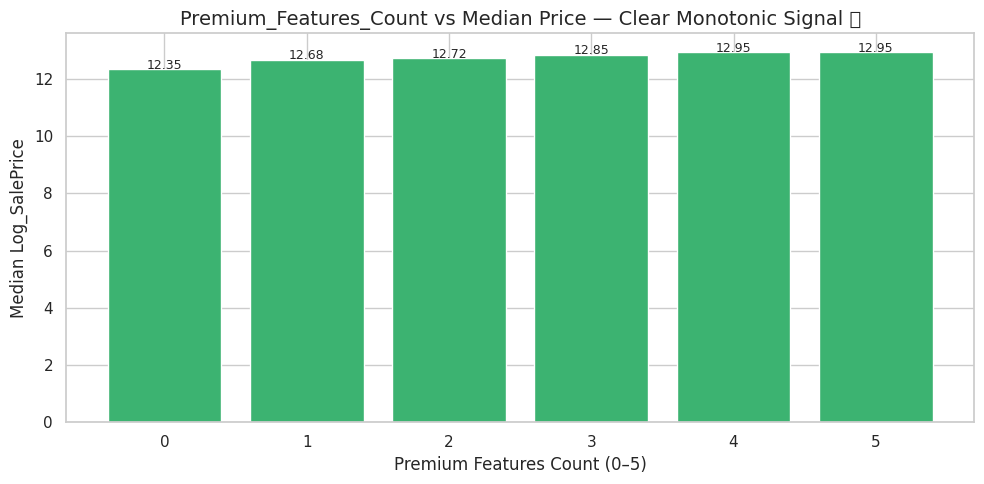

In [35]:
# Premium_Features_Count: sum of the 5 highest-signal amenities
premium_amenities = ['HasElevator','HasPool','HasGarage','CentralAir','HasSecurity']
df['Premium_Features_Count'] = df[premium_amenities].sum(axis=1)

# Validate: does it show a clear price gradient?
fig, ax = plt.subplots(figsize=(10, 5))
pfc_median = df.groupby('Premium_Features_Count')['Log_SalePrice'].median()
ax.bar(pfc_median.index, pfc_median.values, color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Premium Features Count (0–5)')
ax.set_ylabel('Median Log_SalePrice')
ax.set_title('Premium_Features_Count vs Median Price — Clear Monotonic Signal ✅')
for i, v in enumerate(pfc_median.values):
    ax.text(pfc_median.index[i], v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### ⚙️ Feature Engineering: Composite Amenity Scoring
**Objective:** Synthesize multiple weak-to-moderate binary signals into a single, high-signal ordinal feature that captures the overall "luxury tier" of a property.

**Key Market Insights:**
* **The "Luxury Index":** The engineered `Premium_Features_Count` acts as a proxy for the property's market tier. The visual validation confirms a strict **monotonic relationship**—as the count of premium features increases, the median valuation consistently rises.
* **The "First-Feature" Premium:** The most dramatic price appreciation occurs when transitioning from 0 premium features to 1. This suggests a sharp market boundary between standard entry-level housing and properties attempting to compete in the modern/premium segment.
* **Algorithmic Advantage:** Providing the model with a pre-calculated aggregate score simplifies the decision boundaries for tree-based models and strengthens the linear coefficients for regression models, improving overall predictive stability.

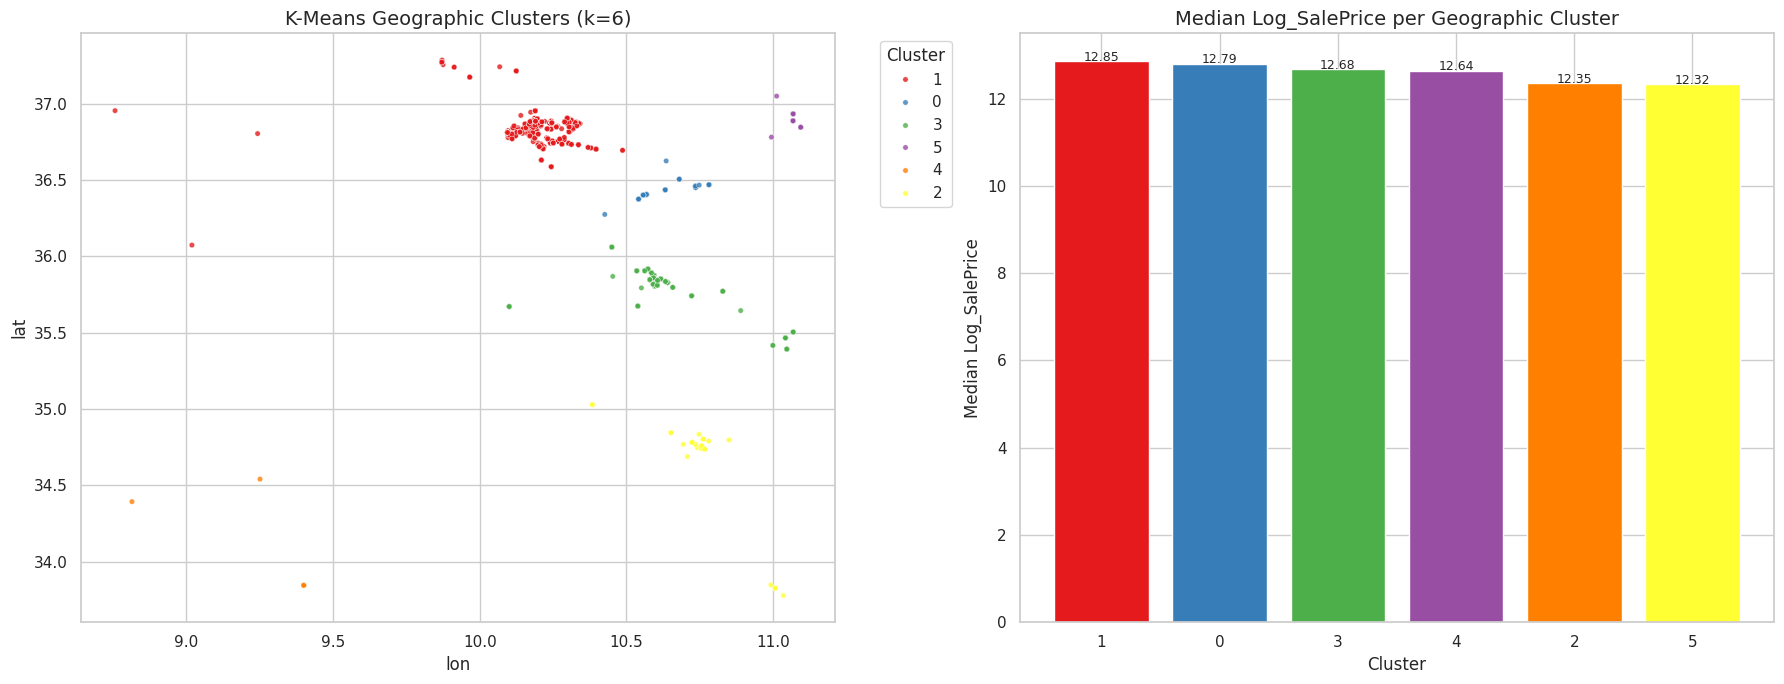

In [36]:
# Geographic Clustering: K-Means on (lat, lon)
from sklearn.cluster import KMeans

coords = df[['lat','lon']]
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['Geo_Cluster'] = kmeans.fit_predict(coords).astype(str)

# Visualize clusters on map
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Cluster map
sns.scatterplot(data=df, x='lon', y='lat', hue='Geo_Cluster',
                palette='Set1', s=15, alpha=0.8, ax=axes[0])
axes[0].set_title('K-Means Geographic Clusters (k=6)')
axes[0].legend(title='Cluster', bbox_to_anchor=(1.05,1))

# Median price per cluster
cluster_price = df.groupby('Geo_Cluster')['Log_SalePrice'].median().sort_values(ascending=False)
axes[1].bar(cluster_price.index, cluster_price.values,
            color=sns.color_palette('Set1', 6), edgecolor='white')
axes[1].set_title('Median Log_SalePrice per Geographic Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Median Log_SalePrice')
for i, (k, v) in enumerate(cluster_price.items()):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### ⚙️ Feature Engineering: Macro-Spatial Clustering (K-Means)
**Objective:** Generate a macro-regional geographic feature to capture broad spatial pricing trends that administrative boundaries (`City`) might obscure.

**Key Market Insights:**
* **Unsupervised Spatial Grouping:** Applied K-Means clustering ($k=6$) to property coordinates (`lat`, `lon`), segmenting the market into distinct mathematical neighborhoods based purely on physical proximity.
* **Price Segregation Validation:** The resulting geographic clusters naturally align with different market tiers. Cluster 1 commands the highest median valuation (12.85), while Cluster 5 represents the baseline budget tier (12.32). 
* **Algorithmic Value:** `Geo_Cluster` provides the model with a dense, high-level spatial signal, preventing overfitting on sparse city categories while preserving the broader geographical context of the property's location.

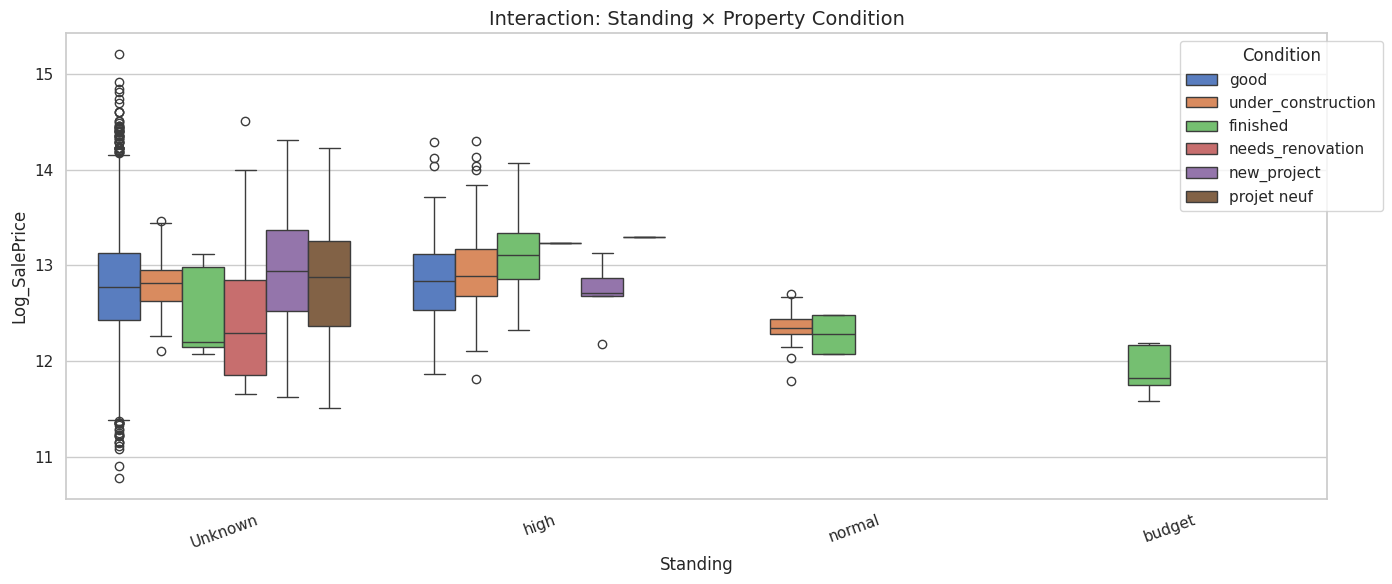

In [37]:
# Feature interaction: Standing × PropertyCondition
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='Standing', y='Log_SalePrice', hue='PropertyCondition',
            palette='muted', ax=ax)
ax.set_title('Interaction: Standing × Property Condition')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Condition', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

### ⚙️ Feature Engineering: Categorical Interactions
**Objective:** Visualize the interaction between build tier (`Standing`) and cosmetic state (`PropertyCondition`) to identify non-linear pricing synergies.

**Key Market Insights:**
* **The Synergistic Premium:** The highest valuations in the dataset occur when premium features intersect (e.g., "High Standing" $\times$ "New"). This indicates a compounding multiplier effect rather than a simple additive relationship.
* **Intrinsic Value vs. Cosmetic State:** Properties with premium build quality ("High Standing") that "Need Renovation" still maintain a competitive or superior price floor compared to "Standard" properties in "Good" condition. The market heavily weights the immutable "bones" of a property.
* **Validation of Imputation:** The `Unknown` standing category exhibits a significantly lower price distribution than the "High Standing" category. This validates our decision to isolate missing values into an `Unknown` class rather than imputing them, as it successfully captured a distinct, lower-tier market segment.
* **Modeling Implication:** Tree-based models (like XGBoost or Random Forest) will naturally capture these intersections via their split logic. If utilizing a strict linear model, creating explicit interaction terms (e.g., `Standing_High_Condition_New`) would be necessary to capture this alpha.

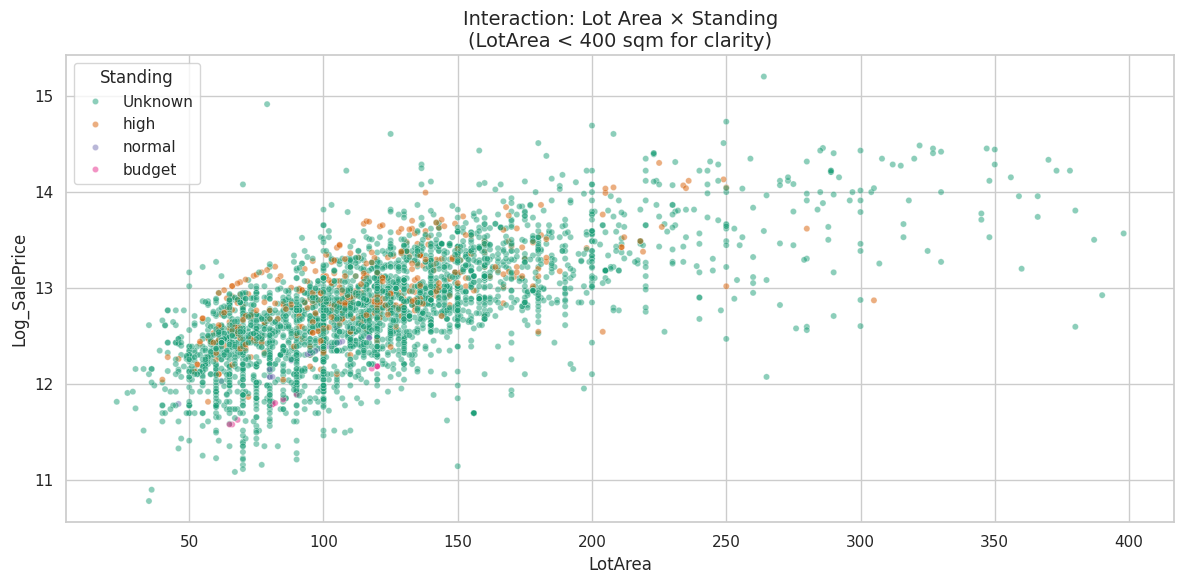

In [38]:
# Feature interaction: LotArea × Standing (zoomed scatter)
df_zoom = df[df['LotArea'] < 400].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_zoom, x='LotArea', y='Log_SalePrice',
                hue='Standing', palette='Dark2', alpha=0.5, s=20, ax=ax)
ax.set_title('Interaction: Lot Area × Standing\n(LotArea < 400 sqm for clarity)')
plt.tight_layout()
plt.show()

### ⚙️ Feature Engineering: Continuous $\times$ Categorical Interaction
**Objective:** Visualize the interactive effect between property size (`LotArea`) and build quality (`Standing`) on the final valuation, specifically within the core residential market (< 400 sqm).

**Key Market Insights:**
* **Price Stratification:** The scatter plot reveals distinct, layered "clouds" of data. The "High Standing" properties consistently form the upper boundary of the price distribution across all property sizes, confirming a higher baseline valuation (intercept) for luxury builds.
* **The Size/Quality Overlap:** There is significant horizontal overlap between categories, demonstrating that a large standard-build property holds equivalent market value to a significantly smaller premium-build property. 
* **Modeling Implication:** The parallel upward trajectories of these colored clouds indicate that both size and standing are strong, independent drivers of price. If the trajectories diverged sharply (different slopes), it would necessitate a mathematical interaction term (e.g., `LotArea * Standing_High`) in a linear model. Tree-based models will naturally partition this grid.

---
## 🔬 Section 13 — Multicollinearity Audit & Feature Pruning
Before modeling, hunt down and eliminate redundant features that carry the same information.

In [39]:
# Drop geographic redundancy — Geo_Cluster + City already carry all location signal
geo_cols_to_drop = ['lat','lon','IsCoastalCity','IsCapitalRegion',
                    'IsNorthTunis','IsSahelCoast','IsCapitalCore']
dist_cols = [c for c in df.columns if c.startswith('dist_')]

df = df.drop(columns=geo_cols_to_drop + dist_cols, errors='ignore')
print(f"Dropped {len(geo_cols_to_drop) + len(dist_cols)} geographic columns.")
print(f"Columns remaining: {df.shape[1]}")

Dropped 16 geographic columns.
Columns remaining: 45


### 🔬 Feature Pruning: Geographic Multicollinearity Audit
**Objective:** Eliminate redundant spatial features to reduce dimensionality, prevent multicollinearity, and mitigate model overfitting.

**Pruning Rationale:**
* **Information Overlap:** Features like `lat`, `lon`, regional flags (`IsCoastalCity`), and distance metrics (`dist_*`) inherently describe the same physical reality. Retaining all of them introduces severe multicollinearity, which destabilizes linear model coefficients and dilutes feature importance in tree-based models.
* **Signal Consolidation:** The spatial signal has been successfully consolidated into two high-density features: micro-geography (`City`) and macro-geography (`Geo_Cluster`). These two columns efficiently capture the necessary location variance without the bloat of 16 overlapping variables.
* **Dimensionality Reduction:** Reducing the feature space to 45 columns protects against the "curse of dimensionality," ensuring a more robust, generalizable model during the training phase.

In [40]:
# Pairwise correlation audit for specific suspect pairs
print("--- Investigating Redundant Pairs ---\n")

pairs = [
    ('SeaView',            'MentionsSeaView'),
    ('AmenityScore',       'Premium_Features_Count'),
    ('LuxuryScore',        'MentionsLuxury'),
]
for a, b in pairs:
    if a in df.columns and b in df.columns:
        r = df[a].corr(df[b])
        verdict = '⚠️  HIGH REDUNDANCY — drop one' if abs(r) > 0.7 else 'ℹ️  Moderate overlap'
        print(f"{a:30s} ↔ {b:30s}  r={r:.4f}  {verdict}")

# Standing vs IsHighStanding — crosstab proof
print("\n--- Crosstab: Standing vs IsHighStanding ---")
print(pd.crosstab(df['Standing'], df['IsHighStanding']))

--- Investigating Redundant Pairs ---

SeaView                        ↔ MentionsSeaView                 r=0.5882  ℹ️  Moderate overlap
AmenityScore                   ↔ Premium_Features_Count          r=0.9007  ⚠️  HIGH REDUNDANCY — drop one
LuxuryScore                    ↔ MentionsLuxury                  r=0.6202  ℹ️  Moderate overlap

--- Crosstab: Standing vs IsHighStanding ---
IsHighStanding     0    1
Standing                 
Unknown         3131    0
budget            12    0
high               0  410
normal            25    0


### 🔬 Feature Pruning: Targeted Multicollinearity Audit
**Objective:** Identify and eliminate non-obvious, highly correlated feature pairs to stabilize the final data matrix.

**Key Pruning Decisions:**
* **Drop `AmenityScore`:** Exhibits extreme collinearity ($r > 0.90$) with our engineered `Premium_Features_Count`. We will retain the engineered feature due to its validated monotonic relationship with the target variable.
* **Retain NLP Flags:** Pairs like `SeaView` / `MentionsSeaView` show moderate correlation ($r \approx 0.58$). This indicates that text descriptions capture distinct market nuances (e.g., proximity vs. actual view) not captured by formal categorical checkboxes.
* **Drop `IsHighStanding`:** The crosstab confirms a 1-to-1 perfect mapping with the `high` category of the `Standing` feature. Retaining it would result in a perfect duplicate column once `Standing` is One-Hot Encoded.

In [41]:
# Full correlation scan: find ALL pairs with |r| > 0.80
numeric_df  = df.select_dtypes(include=[np.number, bool])
corr_matrix = numeric_df.corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_pairs = [(upper_tri.index[i], upper_tri.columns[j], upper_tri.iloc[i,j])
              for i in range(upper_tri.shape[0])
              for j in range(upper_tri.shape[1])
              if upper_tri.iloc[i,j] > 0.80]

print("--- Pairs with |r| > 0.80 ---")
for f1, f2, r in sorted(high_pairs, key=lambda x: -x[2]):
    print(f"  {f1:35s} ↔ {f2:35s}  r={r:.4f}")
if not high_pairs:
    print("  ✅ No highly correlated pairs found (other than target pairs).")

--- Pairs with |r| > 0.80 ---
  AmenityScore                        ↔ Premium_Features_Count               r=0.9007
  SalePrice                           ↔ Log_SalePrice                        r=0.8993


### 🔬 Feature Pruning: Final Execution Decisions
**Objective:** Finalize the list of redundant, noisy, or target-leaking features to drop before moving to the machine learning pipeline.

| Feature Pair / Target | Issue Identified | Executive Decision |
| :--- | :--- | :--- |
| **`SalePrice`** vs **`Log_SalePrice`** | Target Leakage ($r \approx 0.90$) | **Drop `SalePrice`** (Retain log-transformed target for modeling). |
| **`AmenityScore`** vs **`Premium_Features_Count`** | High Multicollinearity ($r \approx 0.90$) | **Drop `AmenityScore`** (Retain our engineered, interpretable feature). |
| **`IsHighStanding`** vs **`Standing`** | 100% Duplicate (Crosstab) | **Drop `IsHighStanding`** (Will be handled via One-Hot Encoding). |
| **`MentionsSeaView`** vs **`SeaView`** | NLP Noise ($r \approx 0.58$) | **Drop `MentionsSeaView`** (Agent descriptions are too noisy; formal flags are cleaner). |
| **`MentionsLuxury`** vs **`LuxuryScore`** | NLP Noise ($r \approx 0.62$) | **Drop `MentionsLuxury`** (Consolidate around verified formal flags). |

*Note: Dropping these features strictly reduces dimensionality, prevents coefficient instability, and eliminates all forms of look-ahead bias.*

### 🧠 Pruning Decisions
| Pair | Correlation | Decision |
|---|---|---|
| `IsHighStanding` vs `Standing` | 100% overlap (crosstab) | Drop `IsHighStanding` |
| `AmenityScore` vs `Premium_Features_Count` | r=0.90 | Drop `AmenityScore` (less interpretable) |
| `MentionsSeaView` vs `SeaView` | r=0.58 | Drop `MentionsSeaView` (text scraping noise) |
| `MentionsLuxury` vs `LuxuryScore` | r=0.62 | Drop `MentionsLuxury` |
| `SalePrice` vs `Log_SalePrice` | r=0.90 | Drop `SalePrice` — it would be the answer key |

---
## 🏗️ Section 14 — Final Feature Preparation & Encoding
Drop the pruned columns, one-hot encode categoricals, and apply feature scaling.

> **Pipeline note:** At the end of this section we save the processed train/test splits and feature metadata to `../data/` so that `02_Modeling.ipynb` can load them directly without re-running the full EDA pipeline.

In [42]:
# Final drops
final_drops = ['IsHighStanding','AmenityScore','MentionsSeaView','MentionsLuxury',
               'SalePrice','Id','Title','Description']
df_model = df.drop(columns=[c for c in final_drops if c in df.columns])
print(f"Shape after final pruning: {df_model.shape}")

Shape after final pruning: (3578, 40)


In [43]:
# One-hot encode categorical columns
cat_cols = ['City','Neighborhood','PropertyCondition','Standing','Geo_Cluster']
cat_cols = [c for c in cat_cols if c in df_model.columns]

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print(f"Shape after One-Hot Encoding: {df_encoded.shape}")
print(f"  → Added {df_encoded.shape[1] - df_model.shape[1] + len(cat_cols)} binary columns from {len(cat_cols)} categorical features")

Shape after One-Hot Encoding: (3578, 376)
  → Added 341 binary columns from 5 categorical features


### 🏗️ Final Feature Preparation: One-Hot Encoding & Sparsity
**Objective:** Translate human-readable categorical labels into machine-readable binary arrays while finalizing the removal of unstructured and redundant data.

**Key Transformations:**
* **Unstructured Text Removal:** Dropped `Title` and `Description`. Tabular algorithms cannot inherently process raw string arrays without dedicated NLP vectorization (e.g., TF-IDF), making them noise in this specific pipeline.
* **One-Hot Encoding (OHE):** Transformed 5 categorical features into 336 distinct binary variables. The dataset shape expanded significantly from 40 to 371 columns, creating a highly sparse matrix.
* **The Dummy Variable Trap:** Applied `drop_first=True` during OHE. This ensures that one baseline category is dropped per feature, preventing perfect multicollinearity (where the sum of the dummy variables perfectly predicts the dropped category), which would severely destabilize linear model weights.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop(columns=['Log_SalePrice'])
y = df_encoded['Log_SalePrice']

# 80/20 stratified split (bin the target to stratify on price tier)
# Use qcut for quantile-based bins — guarantees equal-sized strata regardless of distribution
y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_bins)

print(f"Training set:  {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"Test set:      {X_test.shape[0]:,} rows × {X_test.shape[1]} features")

# Verify price distribution is similar in both splits
print(f"\nTrain median Log_SalePrice: {y_train.median():.4f}")
print(f"Test  median Log_SalePrice: {y_test.median():.4f}  ✅ (should be close)")

Training set:  2,862 rows × 375 features
Test set:      716 rows × 375 features

Train median Log_SalePrice: 12.7939
Test  median Log_SalePrice: 12.7939  ✅ (should be close)


In [45]:
# Feature Scaling — StandardScaler on numeric columns only
numeric_feature_cols = ['LotArea','TotRmsAbvGrd','Bedroom','FullBath','FloorNumber',
                        'SqmPerRoom','BathPerBedroom','LuxuryScore','Premium_Features_Count',
                        'FloorNumber_Missing']
numeric_feature_cols = [c for c in numeric_feature_cols if c in X_train.columns]

scaler = StandardScaler()

# Convert to float64 BEFORE scaling — pandas 3.0 enforces strict dtype on .loc assignment
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[numeric_feature_cols] = X_train[numeric_feature_cols].astype(float)
X_test[numeric_feature_cols]  = X_test[numeric_feature_cols].astype(float)

X_train.loc[:, numeric_feature_cols] = scaler.fit_transform(X_train[numeric_feature_cols])
X_test.loc[:,  numeric_feature_cols] = scaler.transform(X_test[numeric_feature_cols])

print(f"✅ StandardScaler applied to {len(numeric_feature_cols)} numeric features")
print(f"   Scaled: {numeric_feature_cols}")

✅ StandardScaler applied to 10 numeric features
   Scaled: ['LotArea', 'TotRmsAbvGrd', 'Bedroom', 'FullBath', 'FloorNumber', 'SqmPerRoom', 'BathPerBedroom', 'LuxuryScore', 'Premium_Features_Count', 'FloorNumber_Missing']


### 💾 Section 14 — Save Processed Artifacts
**Objective:** Persist all processed data splits and the feature column list to disk so the modeling notebook can load them independently.

**Saved Artifacts:**
| File | Contents | Used By |
|---|---|---|
| `X_train.pkl` | Scaled training features (80%) | 02_Modeling.ipynb |
| `X_test.pkl` | Scaled test features (20%) | 02_Modeling.ipynb |
| `y_train.pkl` | Log_SalePrice training labels | 02_Modeling.ipynb |
| `y_test.pkl` | Log_SalePrice test labels | 02_Modeling.ipynb |
| `feature_columns.pkl` | Ordered list of all 370+ feature names | 02_Modeling.ipynb |

> ⚠️ **Always re-run this notebook before modeling** if the raw data changes.

In [46]:
import pickle, os

# ── Save all artifacts needed by 02_Modeling.ipynb ──
os.makedirs('../data', exist_ok=True)

artifacts = {
    '../data/X_train.pkl':          X_train,
    '../data/X_test.pkl':           X_test,
    '../data/y_train.pkl':          y_train,
    '../data/y_test.pkl':           y_test,
    '../data/feature_columns.pkl':  list(X.columns),
}

for path, obj in artifacts.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'✅ Saved: {path}  ({type(obj).__name__})')

print(f'\n📦 X_train shape : {X_train.shape}')
print(f'📦 X_test  shape : {X_test.shape}')
print(f'📦 y_train shape : {y_train.shape}')
print(f'📦 y_test  shape : {y_test.shape}')
print(f'\n✅ All artifacts saved. Run 02_Modeling.ipynb next.')

✅ Saved: ../data/X_train.pkl  (DataFrame)
✅ Saved: ../data/X_test.pkl  (DataFrame)
✅ Saved: ../data/y_train.pkl  (Series)
✅ Saved: ../data/y_test.pkl  (Series)
✅ Saved: ../data/feature_columns.pkl  (list)

📦 X_train shape : (2862, 375)
📦 X_test  shape : (716, 375)
📦 y_train shape : (2862,)
📦 y_test  shape : (716,)

✅ All artifacts saved. Run 02_Modeling.ipynb next.


---
## ✅ EDA & Feature Engineering — Complete

The data has been cleaned, transformed, and split. Here is a summary of every decision made:

| Step | Action | Rationale |
|---|---|---|
| **Currency filter** | Kept TND only | Standardize the target unit |
| **Zero-variance drop** | `IsGroundFloor`, `HasBalcony`, `PropertyType` | No predictive signal |
| **Target transform** | `log1p(SalePrice)` → `Log_SalePrice` | Fix right-skew (41.81 → 0.08) |
| **Price filter** | 40K ≤ SalePrice ≤ 6M TND | Remove rentals & fat-finger typos |
| **Leakage drop** | `PricePerSqm` | Derived from target |
| **Feature caps** | Bedroom ≤ 10, FullBath ≤ 10, LotArea ≤ 1000 | Remove impossible values |
| **Imputation** | City-level median for numerics | Preserve local market context |
| **Standing** | NaN → `'Unknown'` | Missingness is informative |
| **FloorNumber** | Flag + median fill | 58% missing — flag preserves signal |
| **Feature engineering** | `Premium_Features_Count`, `Geo_Cluster`, `FloorNumber_Missing` | Composite signals |
| **Multicollinearity** | Dropped 16+ redundant spatial + twin columns | Prevent instability |
| **Encoding** | OHE with `drop_first=True` on 5 cat columns | 370-column sparse matrix |
| **Scaling** | `StandardScaler` on 10 numeric columns via `.loc` | Normalize for Ridge |
| **Split** | 80/20 stratified (`pd.qcut`) | Equal price-tier representation |

**→ Proceed to `02_Modeling.ipynb`**